In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np

import torch
from torch.utils.data import Dataset, DataLoader

from torchdyn.core import NeuralODE

import matplotlib.pyplot as plt
import pickle


Matplotlib is building the font cache; this may take a moment.


# Data Generation

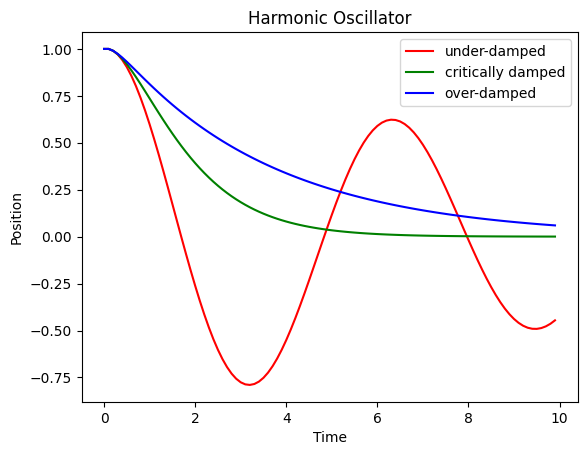

In [3]:
def damped_harmonic_oscillator(x0, v0, m, k, c, t_max=10, dt=0.1):
    """
    Simulate the trajectory of a damped harmonic oscillator
    simple newton method solver

    Args:
        x0 (float): Initial position
        v0 (float): Initial velocity
        m (float): Mass
        k (float): Spring constant
        c (float): Viscous force coefficient
        t_max (float, optional): Maximum time to simulate (default: 10)
        dt (float, optional): Time step (default: 0.01)

    Returns:
        numpy.ndarray: Array of position valuesy
        numpy.ndarray: Array of time values
    """
    t = np.arange(0, t_max, dt)
    x = np.zeros_like(t)
    v = np.zeros_like(t)

    x[0] = x0
    v[0] = v0

    for i in range(1, len(t)):
        a = -c * v[i-1] / m - k * x[i-1] / m  # Acceleration
        v[i] = v[i-1] + a * dt  # Update velocity
        x[i] = x[i-1] + v[i-1] * dt  # Update position

    return x, t

def get_damping_zone(m,k,c):
    zeta = c / (2 * np.sqrt(k * m))
    if zeta > 1:
        return "over-damped"
    if zeta == 1:
        return "critically damped"
    if zeta < 1:
        return "under-damped"
# for simplicity just have it produce trajectories across a range of viscosities
# this is the only conditioned augmented dimension for the proof of concept

x0 = 1.0  # Initial position
v0 = 0.0  # Initial velocity
m = 1.0   # Mass
k = 1.0   # Spring constant
c = np.array([0.25, 2, 3.75]) # np.arange(0.25,5.25,0.25)   # Viscous force coefficient
t_max = 10

X = []
T = [] # same for all unnecessary
labels = []


for ci in c:
    xi,ti = damped_harmonic_oscillator(x0, v0, m, k, ci, t_max)
    labeli = get_damping_zone(m,k,ci)
    X.append(xi)
    T.append(ti)
    labels.append(labeli)


colors = ['red', 'green', 'blue']
for i, x in enumerate(X):
    labeli = labels[i]
    plt.plot(T[i], x, label=labeli, color=colors[i])

# for i, x in enumerate(X):
#     labeli = labels[i]
#     plt.plot(T[i], x, label=labeli)
plt.xlabel('Time')
plt.ylabel('Position')
plt.title(f'Harmonic Oscillator')
plt.legend()
plt.show()
# Create "HADM_ID" column to label the three distinct oscillation groups
hadm_id = [1]*100 + [2]*100 + [3]*100  # Repeats 1, 2, and 3, each 100 times

# Scale time values T to range between 0 and 1
T = [t/10 for t in T]

# # Identify indices where oscillation changes (i.e., where HADM_ID changes)
# end_pt_indices = torch.nonzero(hadm_id[1:] != hadm_id[:-1], as_tuple=False).squeeze() + 1

# Create a DataFrame with the relevant columns
# for this dataset, normalization of x is skipped
df = pd.DataFrame({
    'HADM_ID': hadm_id,
    'x': torch.tensor(np.concatenate(X), dtype=torch.float32).numpy(),
    'c': torch.tensor(c).repeat_interleave(100).type(torch.float32).numpy(),
    't': torch.tensor(np.concatenate(T), dtype=torch.float32).numpy()
})

# # Prepare data dictionary for PyTorch Lightning
# # for this overfitting demo, using the same data for train/val/test
df_all = {'train': df, 'val': df, 'test': df}

file_path = "3Oscillation_data.pkl"
with open(file_path, 'wb') as f:
    pickle.dump(df_all, f)

# Dataloader

In [4]:
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np

class TrainingDataset(Dataset):
    def __init__(self, x0_values, x0_classes, x1_values, times_x0, times_x1):
        self.x0_values = x0_values
        self.x0_classes = x0_classes
        self.x1_values = x1_values
        self.times_x0 = times_x0
        self.times_x1 = times_x1

    def __len__(self):
        return len(self.x0_values)

    def __getitem__(self, idx):
        return (self.x0_values[idx], self.x0_classes[idx], self.x1_values[idx], self.times_x0[idx], self.times_x1[idx])


class PatientDataset(Dataset):
    def __init__(self, patient_data):
        self.patient_data = patient_data

    def __len__(self):
        return len(self.patient_data)

    def __getitem__(self, idx):
        return self.patient_data[idx]


class eICUDataLoader:
    def __init__(self, 
                 file_path, 
                 t_headings,
                 x_headings,
                 cond_headings,
                 memory = 0,
                 batch_size=256, 
                 groupby = 'HADM_ID',
                 train_consecutive=False):
        
        self.batch_size = batch_size
        self.file_path = file_path
        self.x_headings = x_headings
        self.cond_headings = cond_headings
        self.t_headings = t_headings
        self.input_dim = len(self.x_headings) + len(self.cond_headings)
        self.output_dim = len(self.x_headings)
        self.memory = memory
        self.min_timept = 5 + self.memory
        self.train_consecutive = train_consecutive
        self.groupby = groupby

        # Load and setup data
        self.data = pd.read_pickle(self.file_path)
        self.train_data = self.__filter_data(self.data['train'])
        self.val_data = self.__filter_data(self.data['val'])
        self.test_data = self.__filter_data(self.data['test'])

    def __filter_data(self, data_set):
        return data_set.groupby(self.groupby).filter(lambda x: len(x) > self.min_timept)

    def __unpack__(self, data_set):
        x = data_set[self.x_headings].values
        cond = data_set[self.cond_headings].values
        t = data_set[self.t_headings].values
        return x, cond, t
    
    def __sort_group__(self, data_set):
        grouped = data_set.groupby(self.groupby)
        grouped_sorted = grouped.apply(lambda x: x.sort_values([self.t_headings], ascending=True)).reset_index(drop=True)
        return grouped_sorted

    def create_pairs(self, df):
        x0_values = []
        x0_classes = []
        x1_values = []
        times_x0 = []
        times_x1 = []

        for _, group in df.groupby(self.groupby):
            sorted_group = group.sort_values(by=self.t_headings)

            for i in range(self.memory, len(sorted_group) - 1):
                x0 = sorted_group.iloc[i]
                x0_class = x0[self.cond_headings].values
                x0_value = x0[self.x_headings].values

                x1 = sorted_group.iloc[i + 1]
                x1_value = x1[self.x_headings].values

                if self.memory > 0:
                    x0_memory = sorted_group.iloc[i - self.memory:i]
                    x0_memory_flatten = x0_memory[self.x_headings].values.flatten()
                    x0_class = np.append(x0_class, x0_memory_flatten)

                x0_values.append(x0_value)
                x0_classes.append(x0_class)
                x1_values.append(x1_value)
                times_x0.append(x0[self.t_headings])
                times_x1.append(x1[self.t_headings])

        x0_values = np.array(x0_values).squeeze().astype(np.float32)
        x0_classes = np.array(x0_classes).squeeze().astype(np.float32)
        x1_values = np.array(x1_values).squeeze().astype(np.float32)
        times_x0 = np.array(times_x0).squeeze().astype(np.float32)
        times_x1 = np.array(times_x1).squeeze().astype(np.float32)

        # if ==0, shape of (bs, 0) will be kept; 
        # if >=2, shape of (bs, cond_num+dim*memory) will be kept
        if len(self.cond_headings) + self.memory == 1: 
            x0_classes = np.expand_dims(x0_classes, axis=1)
        
        if len(self.x_headings) < 2:
            x0_values = np.expand_dims(x0_values, axis=1)
            x1_values = np.expand_dims(x1_values, axis=1)

        return x0_values, x0_classes, x1_values, times_x0, times_x1

    def create_patient_data(self, df):
        patient_lst = []
        for _, group in df.groupby(self.groupby):
            sorted_group = group.sort_values(by=self.t_headings)
            x0_values, x0_classes, x1_values, times_x0, times_x1 = self.create_pairs(sorted_group)

            patient_lst.append((x0_values,
                                x0_classes,
                                x1_values,
                                times_x0,
                                times_x1))
        return patient_lst

    def create_patient_data_t0(self, df):
        patient_lst = []
        for _, group in df.groupby(self.groupby):
            sorted_group = group.sort_values(by=self.t_headings)
            x0_values, x0_classes, x1_values, times_x0, times_x1 = self.create_pairs(sorted_group)

            if len(self.cond_headings) < 2:
                x0_classes = np.expand_dims(x0_classes, axis=1)
            else:
                x0_classes = x0_classes.squeeze().astype(np.float32)

            x0_values = np.repeat(x0_values[0][None, :], len(x0_values), axis=0)
            x0_classes = np.repeat(x0_classes[0][None, :], len(x0_values), axis=0)
            times_x0 = np.repeat(times_x0[0], len(x0_values))

            patient_lst.append((x0_values.squeeze().astype(np.float32),
                                x0_classes,
                                x1_values.squeeze().astype(np.float32),
                                times_x0.squeeze().astype(np.float32),
                                times_x1.squeeze().astype(np.float32)))
        return patient_lst

    def get_dataloader(self, data, shuffle=True, for_training=True):
        if for_training and self.train_consecutive:
            data = self.create_patient_data_t0(data)
            dataset = PatientDataset(data)
            return DataLoader(dataset, batch_size=1, shuffle=shuffle, num_workers=0)
        elif for_training:
            data = self.create_pairs(data)
            dataset = TrainingDataset(*data)
            return DataLoader(dataset, batch_size=self.batch_size, shuffle=shuffle, num_workers=0)
        else:
            data = self.create_patient_data(data)
            dataset = PatientDataset(data)
            return DataLoader(dataset, batch_size=1, shuffle=shuffle, num_workers=0)

    def get_train_loader(self, shuffle=True):
        return self.get_dataloader(self.train_data, shuffle=shuffle, for_training=True)

    def get_val_loader(self):
        return self.get_dataloader(self.val_data, shuffle=False, for_training=False)

    def get_test_loader(self):
        return self.get_dataloader(self.test_data, shuffle=False, for_training=False)

# Model

In [5]:
class torch_wrapper_tv(torch.nn.Module):
    """Wraps model to torchdyn compatible format."""

    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, t, x, *args, **kwargs):
        return self.model(torch.cat([x, t.repeat(x.shape[0])[:, None]], 1))


class SDE(torch.nn.Module):

    noise_type = "diagonal"
    sde_type = "ito"

    # noise is sigma in this notebook for the equation sigma * (t * (1 - t))
    def __init__(self, ode_drift, noise=1.0, reverse=False):
        super().__init__()
        self.drift = ode_drift
        self.reverse = reverse
        self.noise = noise

    # Drift
    def f(self, t, y):
        if self.reverse:
            t = 1 - t
        if len(t.shape) == len(y.shape):
            x = torch.cat([y, t], 1)
        else:
            x = torch.cat([y, t.repeat(y.shape[0])[:, None]], 1)
        return self.drift(x)

    # Diffusion
    def g(self, t, y):
        return torch.ones_like(t) * torch.ones_like(y) * self.noise


class SDE_func_solver(torch.nn.Module):

    noise_type = "diagonal"
    sde_type = "ito"

    # noise is sigma in this notebook for the equation sigma * (t * (1 - t))
    def __init__(self, ode_drift, noise, reverse=False):
        super().__init__()
        self.drift = ode_drift
        self.reverse = reverse
        self.noise = noise # changeable, a model itself

    # Drift
    def f(self, t, y):
        if self.reverse:
            t = 1 - t
        if len(t.shape) == len(y.shape):
            x = torch.cat([y, t], 1)
        else:
            x = torch.cat([y, t.repeat(y.shape[0])[:, None]], 1)
        return self.drift(x)

    # Diffusion
    def g(self, t, y):
        if self.reverse:
            t = 1 - t
        if len(t.shape) == len(y.shape):
            x = torch.cat([y, t], 1)
        else:
            x = torch.cat([y, t.repeat(y.shape[0])[:, None]], 1)
        noise_result = self.noise(x)
        return noise_result* torch.sqrt(t * (1 - t))
    

def metrics_calculation(pred, true, metrics=['mse_loss'], cutoff=-0.91, map_idx = 1):
    
    # if pred is a tensor, convert to numpy
    if isinstance(pred, torch.Tensor):
        pred = pred.detach().cpu().squeeze().numpy()
        true = true.detach().cpu().squeeze().numpy()

    loss_D = {key : None for key in metrics}
    for metric in metrics:
        if metric == 'mse_loss':
            loss_D['mse_loss'] = np.mean((pred - true)**2)
            # self.log('mse_loss', self.loss_fn(pred, true))
        if metric == 'l1_loss':
            loss_D['l1_loss'] = np.mean(np.abs(pred - true))
            # self.log('l1_loss', torch.mean(torch.abs(pred - true)))

    return loss_D

In [24]:
import torch
import math
import time

import matplotlib.pyplot as plt
import numpy as np
from torchdyn.core import NeuralODE
from torch import optim
import torch.functional as F


PE_BASE = 0.012 # 0.012615662610100801
NUM_FREQS = 10

def positional_encoding_tensor(time_tensor, num_frequencies=NUM_FREQS, base=PE_BASE):
    # Ensure the time tensor is in the range [0, 1]
    time_tensor = time_tensor.clamp(0, 1).unsqueeze(1)  # Clamp and add dimension for broadcasting

    # Compute the arguments for the sine and cosine functions using the custom base
    frequencies = torch.pow(base, -torch.arange(0, num_frequencies, dtype=torch.float32) / num_frequencies)
    angles = time_tensor * frequencies

    # Compute the sine and cosine for even and odd indices respectively
    sine = torch.sin(angles)
    cosine = torch.cos(angles)

    # Stack them along the last dimension
    pos_encoding = torch.stack((sine, cosine), dim=-1)
    pos_encoding = pos_encoding.flatten(start_dim=2)

    # Normalize to have values between 0 and 1
    pos_encoding = (pos_encoding + 1) / 2  # Now values are between 0 and 1
    
    return pos_encoding

class MLP_conditional_memory(torch.nn.Module):
    """ Conditional with many available classes

    return the class as is
    """
    def __init__(self, 
                 dim, 
                 treatment_cond,
                 memory, # how many time steps
                 out_dim=None, 
                 w=64, 
                 time_varying=False, 
                 conditional=False,  
                 time_dim = NUM_FREQS * 2,
                 clip = None,
                 ):
        super().__init__()
        self.time_varying = time_varying
        if out_dim is None:
            self.out_dim = dim 
        self.out_dim += 1 # for the time dimension
        self.treatment_cond = treatment_cond
        self.memory = memory
        self.dim = dim
        self.indim = dim + (time_dim if time_varying else 0) + (self.treatment_cond if conditional else 0) + (dim * memory)
        self.net = torch.nn.Sequential(
            torch.nn.Linear(self.indim, w),
            torch.nn.SELU(),
            torch.nn.Linear(w, w),
            torch.nn.SELU(),
            torch.nn.Linear(w, w),
            torch.nn.SELU(),
            torch.nn.Linear(w,self.out_dim),
        )
        self.default_class = 0
        self.clip = clip

    def encoding_function(self, time_tensor):
        return positional_encoding_tensor(time_tensor)    

    def forward_train(self, x):
        """forward pass
        Assume first two dimensions are x, c, then t
        """
        time_tensor = x[:,-1]
        encoded_time_span = self.encoding_function(time_tensor).reshape(-1, NUM_FREQS * 2)
        new_x = torch.cat([x[:,:-1], encoded_time_span], dim=1)
        result = self.net(new_x)
        return torch.cat([result[:,:-1], x[:,self.dim:-1], result[:,-1].unsqueeze(1)], dim=1)

    def forward(self, x):
        """ call forward_train for training
            x here is x_t
            xt = (t)x1 + (1-t)x0
            (xt - tx1)/(1-t) = x0
        """
        x1 = self.forward_train(x)
        x1_coord = x1[:,:self.dim]
        t = x[:,-1]
        pred_time_till_t1 = x1[:,-1]
        x_coord = x[:,:self.dim]
        if self.clip is None:
            vt = (x1_coord - x_coord)/(pred_time_till_t1)
        else:
            vt = (x1_coord - x_coord)/torch.clip((pred_time_till_t1),min=self.clip)

        final_vt = torch.cat([vt, torch.zeros_like(x[:,self.dim:-1])], dim=1)
        return final_vt

class MLP_conditional_memory_sde_noise(torch.nn.Module):
    """ Conditional with many available classes

    return the class as is
    """
    def __init__(self, 
                 dim, 
                 treatment_cond,
                 memory, # how many time steps
                 out_dim=None, 
                 w=64, 
                 time_varying=False, 
                 conditional=False,  
                 time_dim = NUM_FREQS * 2,
                 clip = None,
                 ):
        super().__init__()
        self.time_varying = time_varying
        if out_dim is None:
            self.out_dim = 1 # for noise 
        self.treatment_cond = treatment_cond
        self.memory = memory
        self.dim = dim
        self.indim = dim + (time_dim if time_varying else 0) + (self.treatment_cond if conditional else 0) + (dim * memory)
        self.net = torch.nn.Sequential(
            torch.nn.Linear(self.indim, w),
            torch.nn.SELU(),
            torch.nn.Linear(w, w),
            torch.nn.SELU(),
            torch.nn.Linear(w, w),
            torch.nn.SELU(),
            torch.nn.Linear(w,self.out_dim),
        )
        self.default_class = 0
        self.clip = clip

    def encoding_function(self, time_tensor):
        return positional_encoding_tensor(time_tensor)    

    def forward_train(self, x):
        """forward pass
        Assume first two dimensions are x, c, then t
        """
        time_tensor = x[:,-1]
        encoded_time_span = self.encoding_function(time_tensor).reshape(-1, NUM_FREQS * 2)
        new_x = torch.cat([x[:,:-1], encoded_time_span], dim=1)
        result = self.net(new_x)
        return result
    
    def forward(self,x):
        result = self.forward_train(x)
        return torch.cat([result, torch.zeros_like(x[:,1:-1])], dim=1)

def mse_loss(pred, true):
    return torch.mean((pred - true) ** 2)

class Noise_MLP_Cond_Memory_Module(torch.nn.Module):
    def __init__(self, treatment_cond, memory=3, dim=2, w=64, time_varying=True, conditional=True, lr=1e-6, sigma=0.1, 
                 loss_fn=mse_loss, metrics=['mse_loss', 'l1_loss'], implementation="ODE", sde_noise=0.1, clip=None, naming=None):
        super().__init__()
        self.flow_model = MLP_conditional_memory(dim=dim, w=w, time_varying=time_varying, conditional=conditional, 
                                                 treatment_cond=treatment_cond, memory=memory, clip=clip)
        if implementation == "SDE":
            self.noise_model = MLP_conditional_memory_sde_noise(dim=dim, w=w, time_varying=time_varying, conditional=conditional, 
                                                                treatment_cond=treatment_cond, memory=memory, clip=clip)
        else:
            self.noise_model = MLP_conditional_memory(dim=dim, w=w, time_varying=time_varying, conditional=conditional, 
                                                      treatment_cond=treatment_cond, memory=memory, clip=clip)
        self.loss_fn = loss_fn
        self.dim = dim
        self.w = w
        self.time_varying = time_varying
        self.conditional = conditional
        self.treatment_cond = treatment_cond
        self.lr = lr
        self.sigma = sigma
        self.metrics = metrics
        self.implementation = implementation
        self.memory = memory
        self.sde_noise = sde_noise
        self.clip = clip

    def forward(self, x):
        return self.flow_model(x)

    def configure_optimizers(self):
        flow_optimizer = torch.optim.Adam(self.flow_model.parameters(), lr=self.lr)
        noise_optimizer = torch.optim.Adam(self.noise_model.parameters(), lr=self.lr)
        return flow_optimizer, noise_optimizer

    def __convert_tensor__(self, tensor):
        return tensor.to(torch.float32)

    def __x_processing__(self, x0, x1, t0, t1):
        t = torch.rand(x0.shape[0], 1).to(x0.device)
        mu_t = x0 * (1 - t) + x1 * t
        data_t_diff = (t1 - t0).unsqueeze(1)
        x = mu_t + self.sigma * torch.randn(x0.shape[0], self.dim).to(x0.device)
        ut = (x1 - x0) / (data_t_diff + 1e-4)
        t_model = t * data_t_diff + t0.unsqueeze(1)
        futuretime = t1 - t_model
        return x, ut, t_model, futuretime, t

class MLP_Cond_Memory_Module(torch.nn.Module):
    def __init__(self, treatment_cond, memory=3, dim=2, w=64, time_varying=True, conditional=True, lr=1e-6, sigma=0.1, 
                 loss_fn=mse_loss, metrics=['mse_loss', 'l1_loss'], implementation="ODE", sde_noise=0.1, clip=None, naming=None):
        super().__init__()
        self.model = MLP_conditional_memory(dim=dim, w=w, time_varying=time_varying, conditional=conditional, 
                                            treatment_cond=treatment_cond, memory=memory, clip=clip)
        self.loss_fn = loss_fn
        self.dim = dim
        self.w = w
        self.time_varying = time_varying
        self.conditional = conditional
        self.treatment_cond = treatment_cond
        self.lr = lr
        self.sigma = sigma
        self.metrics = metrics
        self.implementation = implementation
        self.memory = memory
        self.sde_noise = sde_noise
        self.clip = clip

    def forward(self, x):
        return self.model(x)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)
        return optimizer

    def __convert_tensor__(self, tensor):
        return tensor.to(torch.float32)

    def __x_processing__(self, x0, x1, t0, t1):
        t = torch.rand(x0.shape[0], 1).to(x0.device)
        mu_t = x0 * (1 - t) + x1 * t
        data_t_diff = (t1 - t0).unsqueeze(1)
        x = mu_t + self.sigma * torch.randn(x0.shape[0], self.dim).to(x0.device)
        ut = (x1 - x0) / (data_t_diff + 1e-4)
        t_model = t * data_t_diff + t0.unsqueeze(1)
        futuretime = t1 - t_model
        return x, ut, t_model, futuretime, t
    
    def to(self, device):
        """Move the model to specified device"""
        self.model = self.model.to(device)
        return self


In [32]:
def train_model(model, noise_prediction, train_loader, val_loader=None, num_epochs=10, device='cuda'):
    model.to(device)

    # with noise prediction
    if noise_prediction: 
        flow_optimizer, noise_optimizer = model.configure_optimizers()
    # without noise prediction
    else: 
        optimizer = model.configure_optimizers()

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for batch in train_loader:
            x0, x0_class, x1, x0_time, x1_time = [b.to(device) for b in batch]

            x, ut, t_model, futuretime, t = model.__x_processing__(x0, x1, x0_time, x1_time)

            in_tensor = torch.cat([x, x0_class, t_model], dim=-1)

            # with noise prediction
            if noise_prediction: 
                xt = model.flow_model.forward_train(in_tensor)

                if model.implementation == "SDE":
                    sde_noise = model.noise_model.forward_train(in_tensor)
                    variance = torch.sqrt(t * (1 - t)) * sde_noise
                    noise = torch.randn_like(xt[:, :model.dim]) * variance
                    loss = model.loss_fn(xt[:, :model.dim] + noise.clone().detach(), x1) + model.loss_fn(xt[:, -1], futuretime)
                    uncertainty = (xt[:, :model.dim].clone().detach() + noise)
                    noise_loss = model.loss_fn(uncertainty, x1)
                else:
                    loss = model.loss_fn(xt[:, :model.dim], x1) + model.loss_fn(xt[:, -1], futuretime)
                    uncertainty = torch.abs(xt[:, :model.dim].clone().detach() - x1)
                    noise_loss = model.loss_fn(model.noise_model.forward_train(in_tensor)[:, :model.dim], uncertainty)

                flow_optimizer.zero_grad()
                loss.backward()
                flow_optimizer.step()

                noise_optimizer.zero_grad()
                noise_loss.backward()
                noise_optimizer.step()

                train_loss += (loss + noise_loss).item()

            # without noise prediction
            else: 
                xt = model.model.forward_train(in_tensor)

                if model.implementation == "SDE":
                    variance = t * (1 - t) * model.sde_noise
                    noise = torch.randn_like(xt[:, :model.dim]) * torch.sqrt(variance)
                    loss = model.loss_fn(xt[:, :model.dim] + noise, x1) # + model.loss_fn(xt[:, -1], futuretime)
                else:
                    loss = model.loss_fn(xt[:, :model.dim], x1) # + model.loss_fn(xt[:, -1], futuretime)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                train_loss += loss.item()

        # validation
        if (epoch+1) % 100 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {train_loss/len(train_loader)}")
            if val_loader: 
                test_model(model, noise_prediction, val_loader, device)

def test_model(model, noise_prediction, test_loader, device):
    model.eval()  # Set the model to evaluation mode
    list_of_pairs = []
    list_of_times = []

    dict_full_trajs = {}
    dict_pred_trajs = {}

    loss_sum = 0
    with torch.no_grad():
        for batch_idx, batch in enumerate(test_loader):
            batch = [x.to(device) for x in batch]
            loss, pairs, metricD, noise_loss, noise_pair, full_time = test_func_step(batch, batch_idx, model, noise_prediction)
            list_of_pairs.append(pairs)
            list_of_times.append(full_time)
            full_traj = pairs[0][0]
            pred_traj = pairs[0][1]
            dict_full_trajs[batch_idx] = full_traj.detach().cpu().numpy()
            dict_pred_trajs[batch_idx] = pred_traj.detach().cpu().numpy()
            loss_sum += loss

        fig = plt.figure(figsize=(5, 4))
        ax = fig.add_subplot(111)
        colors = ['red', 'green', 'blue']
        T = np.arange(0,1,0.01)
        count = 0
        for _,v in dict_pred_trajs.items():
            ax.plot(T[model.memory:], v, label="predicted" if count == 0 else '', color=colors[count])
            count += 1
        count = 0
        for _,v in dict_full_trajs.items():
            ax.plot(T[model.memory:], v, label="ground truth" if count == 0 else '', color=colors[count], linestyle='--')
            count += 1

        ax.set_xlabel('scaled t', fontsize='10')
        ax.set_ylabel('x', fontsize='10')
        # ax.set_title("damped_oscillations_epoch_{}".format(self.current_epoch))
        ax.legend(fontsize='10')
        plt.tight_layout()
        plt.show()
        plt.close()
    print(f"validation loss: {loss_sum/len(test_loader)}")

def test_func_step(batch, batch_idx, model, noise_prediction):
    """Assuming each batch is one patient"""
    total_loss = []
    traj_pairs = []

    total_noise_loss = []
    noise_pairs = []

    x0_values, x0_classes, x1_values, times_x0, times_x1 = batch
    times_x0 = times_x0.squeeze()
    times_x1 = times_x1.squeeze()

    full_traj = torch.cat([x0_values[0, 0, :model.dim].unsqueeze(0), x1_values[0, :, :model.dim]], dim=0)
    full_time = torch.cat([times_x0[0].unsqueeze(0), times_x1], dim=0)
    # print(f"full_traj {full_traj.shape}")
    # print(f"full_time {full_time.shape}")

    if model.implementation == "ODE":
        ind_loss, pred_traj, noise_mse, noise_pred = test_trajectory_ode(batch, model, noise_prediction)
    elif model.implementation == "SDE":
        ind_loss, pred_traj, noise_mse, noise_pred = test_trajectory_sde(batch, model, noise_prediction)

    # print(f"pred_traj {pred_traj.shape}")

    total_loss.append(ind_loss)
    traj_pairs.append([full_traj, pred_traj])
    noise_pairs.append([full_traj, noise_pred])
    total_noise_loss.append(noise_mse)

    # Optionally detach and move tensors to CPU for further processing or visualization
    full_traj = full_traj.detach().cpu().numpy()
    pred_traj = pred_traj.detach().cpu().numpy()
    full_time = full_time.detach().cpu().numpy()

    # # Generate the plot
    # fig = plot_3d_path_ind_noise(pred_traj, full_traj, noise_pred, t_span=full_time, title=f"trajectory_patient_{batch_idx}")
    
    # plt.close(fig)

    # Calculate metrics
    metricD = metrics_calculation(pred_traj, full_traj)
    return np.mean(total_loss), traj_pairs, metricD, np.mean(total_noise_loss), noise_pairs, full_time
    
def test_trajectory_ode(batch, model, noise_prediction): # have to squeeze here to adjust for bs=1
    # with noise prediction
    
    if noise_prediction:
        node = NeuralODE(torch_wrapper_tv(model.flow_model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4)
        node_noise = NeuralODE(torch_wrapper_tv(model.noise_model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4)
    else:
        node = NeuralODE(torch_wrapper_tv(model.model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4)
    total_pred, noise_pred = [], []
    mse, noise_mse = [], []
    total_pred = []
    mse = []

    x0_values, x0_classes, x1_values, times_x0, times_x1 = batch
    # print("="*10)
    # print("HERE test_trajectory ode")
    # print(f"x0 from dataloader {x0_values.shape}")
    # print(f"cond from dataloader {x0_classes.shape}")
    # print(f"x1 from dataloader {x1_values.shape}")
    # print(f"t0 from dataloader {times_x0.shape}")
    # print(f"t1 from dataloader {times_x1.shape}")
    # print(f"t0[0] {times_x0[0].shape}")
    # print(f"t1[0] {times_x1[0].shape}")
    # print(f"history {x0_classes[0][-(model.memory * model.dim):].shape}")
    # print(f"x0_values.shape[0] {x0_values.shape[0]}")
    # print(f"x1_values.shape[0] {x1_values.shape[0]}")
    x0_values = x0_values.squeeze(0)
    x0_classes = x0_classes.squeeze(0)
    x1_values = x1_values.squeeze(0)
    times_x0 = times_x0.squeeze()
    times_x1 = times_x1.squeeze()
    # print(f"x0 squeezed {x0_values.shape}")
    # print(f"cond squeezed {x0_classes.shape}")
    # print(f"x1 squeezed {x1_values.shape}")
    # print(f"t0 squeezed {times_x0.shape}")
    # print(f"t1 squeezed {times_x1.shape}")

    total_pred.append(x0_values[0].unsqueeze(0))
    len_path = x0_values.shape[0]
    # assert len_path == x1_values.shape[0]

    if model.memory > 0:
        time_history = x0_classes[0][-(model.memory * model.dim):]

    for i in range(len_path):
        time_span = torch.linspace(times_x0[i], times_x1[i], 10).to(x0_values.device)

        # print("-"*10)
        # print(f"i {i}")

        if model.memory > 0:
            # print(f"cond memory>0 part 1 shape {x0_classes[i][:-(model.memory * model.dim)].unsqueeze(0).shape}")
            # print(f"cond memory>0 part 1 {x0_classes[i][:-(model.memory * model.dim)].unsqueeze(0)}")
            # print(f"cond memory>0 part 2 shape {time_history.unsqueeze(0).shape}")
            # print(f"cond memory>0 part 2 {time_history.unsqueeze(0)}")
            new_x_classes = torch.cat([x0_classes[i][:-(model.memory * model.dim)].unsqueeze(0), time_history.unsqueeze(0)], dim=1)
            # print(new_x_classes.shape)
            # print(x0_classes[i].shape)
        else:
            new_x_classes = x0_classes[i].unsqueeze(0)
            # print(f"cond memory=0 {new_x_classes.shape}")

        with torch.no_grad():
            if i == 0: # TODO: here is the issue to fix. Seems to be wrong for the paper figure generation
                # testpt = torch.cat([x0_values[i].unsqueeze(0), new_x_classes], dim=1)
                testpt = torch.cat([x0_values[i].unsqueeze(0), x0_classes[i].unsqueeze(0)], dim=1)
                # print(f"testpt at i==0 {testpt.shape}")
            else:
                # testpt = torch.cat([pred_traj, new_x_classes], dim=1)
                testpt = torch.cat([pred_traj, x0_classes[i].unsqueeze(0)], dim=1)
                # print(f"testpt at i!=0 {testpt.shape}")
                
            traj = node.trajectory(testpt, t_span=time_span)
            if noise_prediction:
                noise_traj = node_noise.trajectory(testpt, t_span=time_span)

        pred_traj = traj[-1, :, :model.dim]
        total_pred.append(pred_traj)
        if noise_prediction:
            noise_traj = noise_traj[-1, :, :model.dim]
            noise_pred.append(noise_traj)
        

        ground_truth_coords = x1_values[i]
        mse_traj = model.loss_fn(pred_traj, ground_truth_coords).detach().cpu().numpy()
        mse.append(mse_traj)
        if noise_prediction:
            uncertainty_traj = ground_truth_coords - pred_traj
            noise_mse_traj = model.loss_fn(noise_traj, uncertainty_traj).detach().cpu().numpy()
            noise_mse.append(noise_mse_traj)

        
        if model.memory > 0:
            flattened_coords = pred_traj.flatten()
            time_history = torch.cat([time_history[model.dim:].unsqueeze(0), flattened_coords.unsqueeze(0)], dim=1).squeeze()

    mse_all = np.mean(mse)
    total_pred_tensor = torch.stack(total_pred).squeeze(1)
    if noise_prediction:
        noise_pred = torch.stack(noise_pred).squeeze(1)
    
    return mse_all, total_pred_tensor, noise_mse, noise_pred


def test_trajectory_sde(batch, model, noise_prediction):
    if noise_prediction:
        sde = SDE_func_solver(model.flow_model, noise=model.noise_model)
    else:
        sde = SDE(model.model, noise=0.1)
    total_pred, noise_pred = [], []
    mse, noise_mse = []

    x0_values, x0_classes, x1_values, times_x0, times_x1 = batch
    x0_values = x0_values.squeeze(0)
    x0_classes = x0_classes.squeeze(0)
    x1_values = x1_values.squeeze(0)
    times_x0 = times_x0.squeeze()
    times_x1 = times_x1.squeeze()

    # if len(x0_classes.shape) == 1:
    #     x0_classes = x0_classes.unsqueeze(1)

    total_pred.append(x0_values[0].unsqueeze(0))
    len_path = x0_values.shape[0]
    assert len_path == x1_values.shape[0]

    if model.memory > 0:
        time_history = x0_classes[0][-(model.memory * model.dim):]

    for i in range(len_path):
        time_span = torch.linspace(times_x0[i], times_x1[i], 10).to(x0_values.device)

        if model.memory > 0:
            new_x_classes = torch.cat([x0_classes[i][:-(model.memory * model.dim)].unsqueeze(0), time_history.unsqueeze(0)], dim=1)
        else:
            new_x_classes = x0_classes[i]

        with torch.no_grad():
            if i == 0:
                testpt = torch.cat([x0_values[i].unsqueeze(0), new_x_classes], dim=1)
            else:
                testpt = torch.cat([pred_traj, new_x_classes], dim=1)
                
            traj, noise_traj = _sde_solver(sde, testpt, time_span)

        pred_traj = traj[-1, :, :model.dim]
        noise_traj = noise_traj[-1, :, :model.dim]

        total_pred.append(pred_traj)
        if noise_prediction:
            noise_pred.append(noise_traj)

        ground_truth_coords = x1_values[i]
        mse_traj = model.loss_fn(pred_traj, ground_truth_coords).detach().cpu().numpy()
        mse.append(mse_traj)
        noise_mse.append(mse_traj)

        if model.memory > 0:
            flattened_coords = pred_traj.flatten()
            time_history = torch.cat([time_history[model.dim:].unsqueeze(0), flattened_coords.unsqueeze(0)], dim=1).squeeze()

    mse_all = np.mean(mse)
    noise_mse_all = np.mean(noise_mse)
    total_pred_tensor = torch.stack(total_pred).squeeze(1)
    if noise_prediction:
        noise_pred_tensor = torch.stack(noise_pred).squeeze(1)
    return mse_all, total_pred_tensor, noise_mse_all, noise_pred_tensor

def _sde_solver(sde, initial_state, time_span):
    dt = time_span[1] - time_span[0]
    current_state = initial_state
    trajectory = [current_state]
    noise_trajectory = []

    for t in time_span[1:]:
        drift = sde.f(t, current_state)
        diffusion = sde.g(t, current_state)
        noise = torch.randn_like(current_state) * torch.sqrt(dt)
        current_state = current_state + drift * dt + diffusion * noise
        trajectory.append(current_state)
        noise_trajectory.append(diffusion * noise)

    return torch.stack(trajectory), torch.stack(noise_trajectory)

# train experiments

In [26]:
data_loader_1d_3m = eICUDataLoader(batch_size=512, file_path=file_path, 
                             t_headings=['t'],
                             x_headings=['x'],
                             cond_headings=[],
                             memory=3)

train_loader_1d_3m = data_loader_1d_3m.get_train_loader(shuffle=True)
val_loader_1d_3m = data_loader_1d_3m.get_val_loader()

Epoch 100/1000, Loss: 0.0017163190059363842


/Users/skul/GitHub/TrajectoryFlowMatching/.conda/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/skul/GitHub/TrajectoryFlowMatching/.conda/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


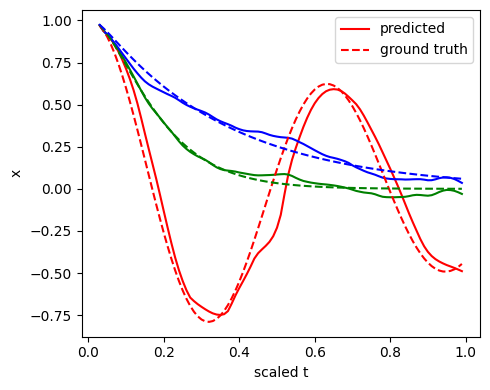

validation loss: 0.005634263041429222
Epoch 200/1000, Loss: 0.0009461824665777385


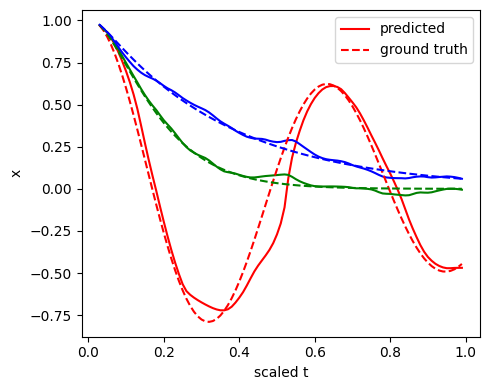

validation loss: 0.005449875044481208
Epoch 300/1000, Loss: 0.000409832427976653


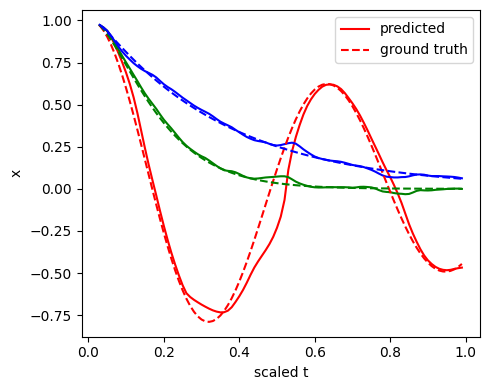

validation loss: 0.003956760735794281
Epoch 400/1000, Loss: 0.0002166853955714032


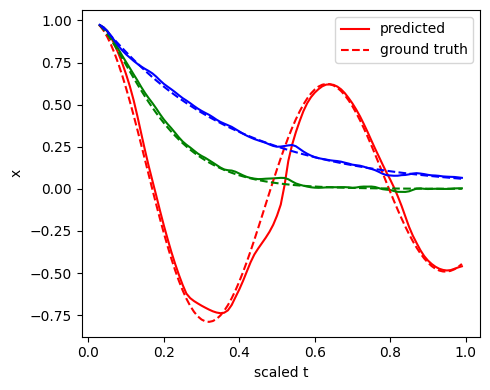

validation loss: 0.0022947858136224872
Epoch 500/1000, Loss: 0.00010524263780098408


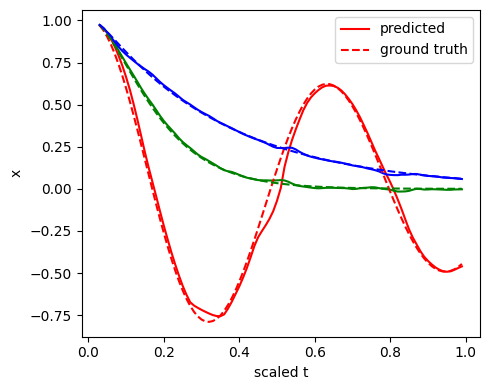

validation loss: 0.001030059102049563
Epoch 600/1000, Loss: 5.660103852278553e-05


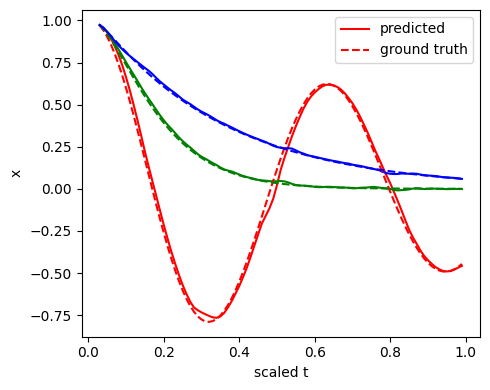

validation loss: 0.0005506554941045275
Epoch 700/1000, Loss: 0.00012093293480575085


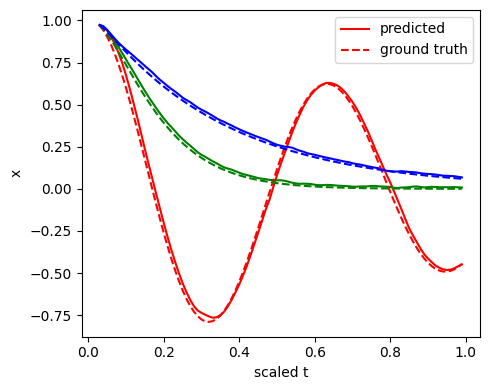

validation loss: 0.0006737632647855207
Epoch 800/1000, Loss: 3.953966006520204e-05


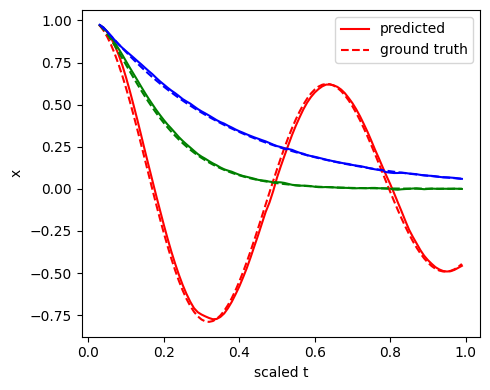

validation loss: 0.0004534873454152451
Epoch 900/1000, Loss: 2.8926391678396612e-05


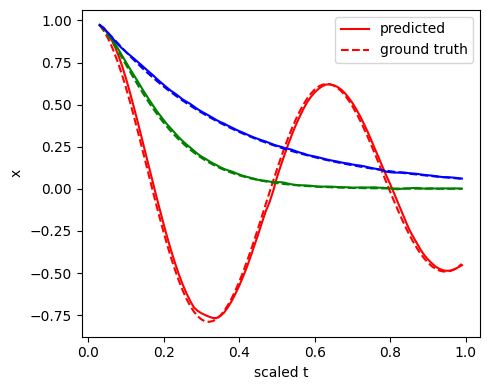

validation loss: 0.00042165806856549654
Epoch 1000/1000, Loss: 3.377796383574605e-05


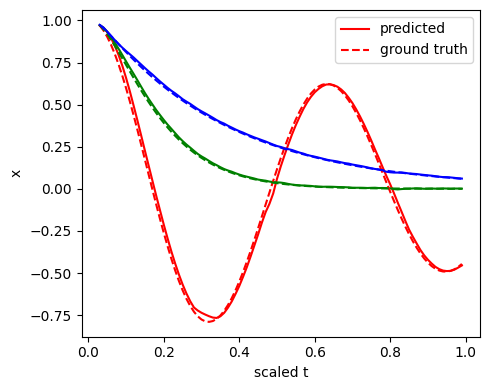

validation loss: 0.00045603009978852543


In [35]:
import random
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

# Create the model instance
model = MLP_Cond_Memory_Module(treatment_cond=0, memory=3, 
                                     dim=1, w=256, 
                                     time_varying=True, 
                                     conditional=False, 
                                     lr=1e-3, 
                                     sigma=0.1, 
                                     loss_fn=mse_loss, 
                                     metrics=['mse_loss'], 
                                     implementation="ODE", 
                                     sde_noise=0.1, 
                                     clip=0.01)

# Train the model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
train_model(model, False, train_loader_1d_3m, val_loader_1d_3m, num_epochs=1000, device=device)

In [60]:
import sys
import os
sys.path.append(os.path.abspath('..'))  # Adjust the path as needed to point to your project root
from src.utils.non_markovian_sde import NonMarkovianSDEModel


Model structure:
NonMarkovianSDEModel(
  (flow_model): NonMarkovianDriftNet(
    (net): Sequential(
      (0): Linear(in_features=6, out_features=64, bias=True)
      (1): SELU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): SELU()
      (4): Linear(in_features=64, out_features=64, bias=True)
      (5): SELU()
      (6): Linear(in_features=64, out_features=2, bias=True)
    )
  )
  (noise_model): NonMarkovianNoiseNet(
    (net): Sequential(
      (0): Linear(in_features=6, out_features=64, bias=True)
      (1): SELU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): SELU()
      (4): Linear(in_features=64, out_features=64, bias=True)
      (5): SELU()
      (6): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)


/var/folders/93/ntgmx7vs74j7k7hwjjw8n70m0000gn/T/ipykernel_15804/3991996460.py:123: UserWarning: Using a target size (torch.Size([297, 1])) that is different to the input size (torch.Size([297])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  F.mse_loss(xt[:, -1], futuretime)


Epoch 100/1000, Loss: 0.6048504114151001


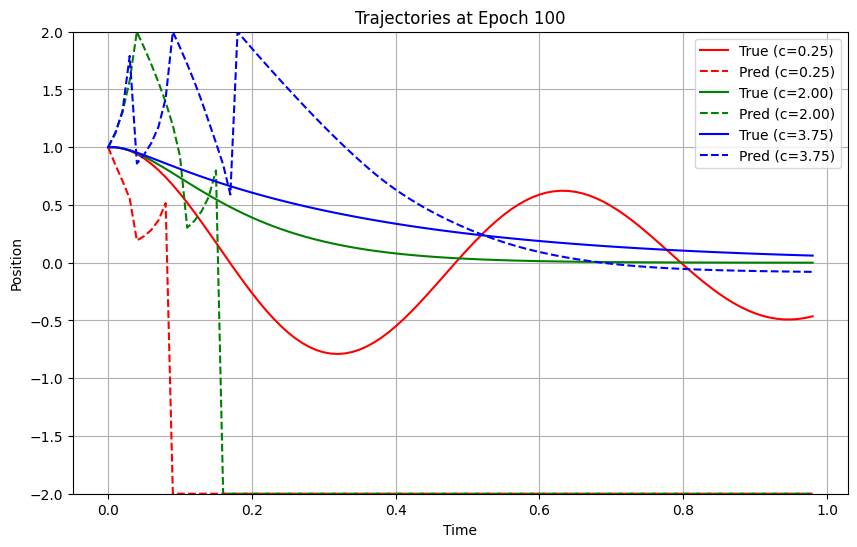

Epoch 200/1000, Loss: 0.5673437118530273


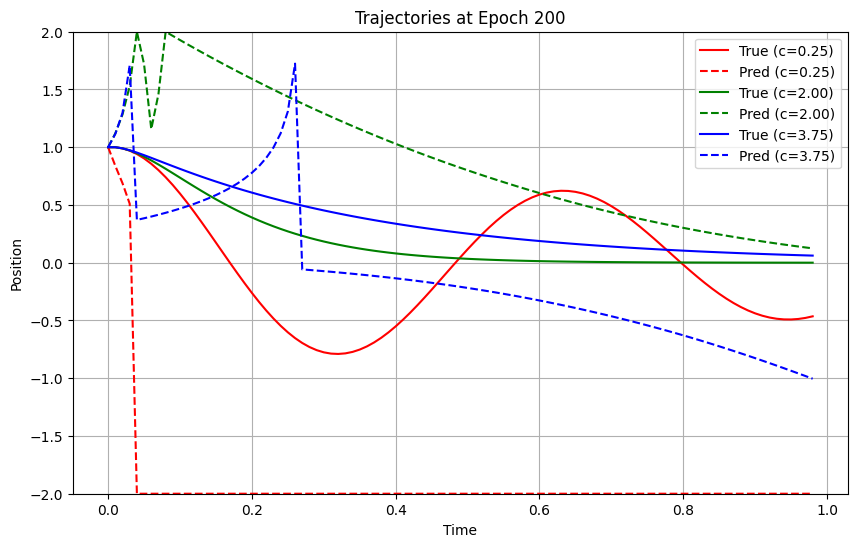

Epoch 300/1000, Loss: 0.5393210649490356


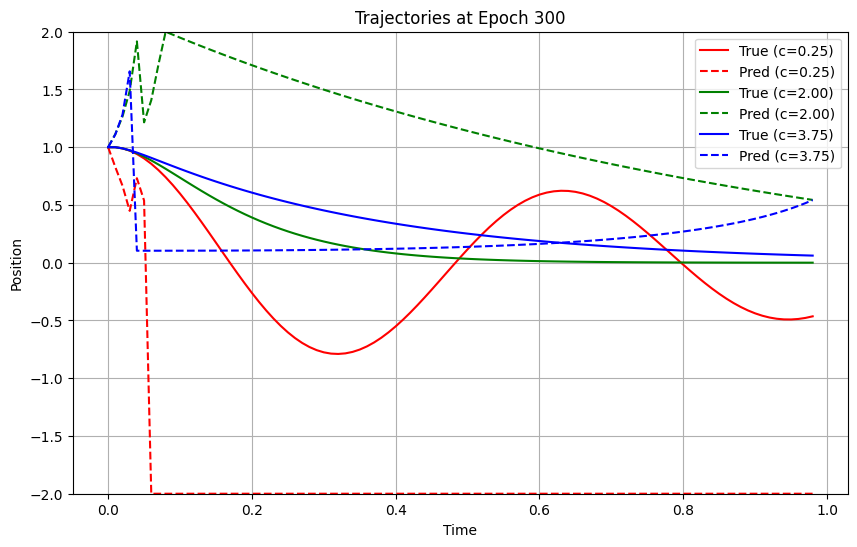

Epoch 400/1000, Loss: 0.5095696449279785


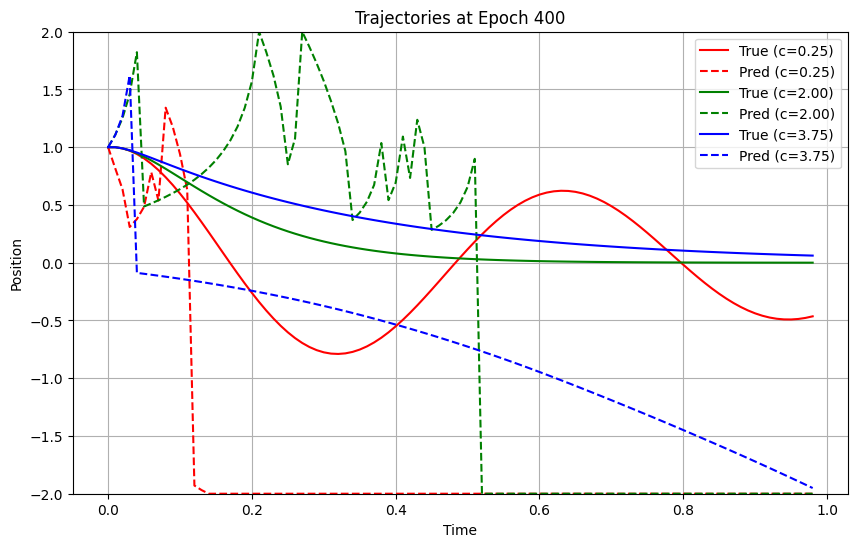

Epoch 500/1000, Loss: 0.48534971475601196


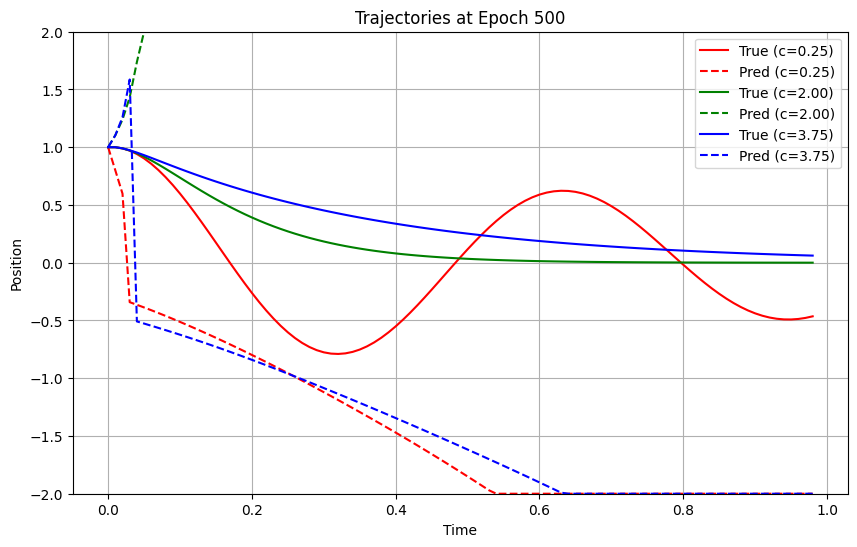

Epoch 600/1000, Loss: 0.46924567222595215


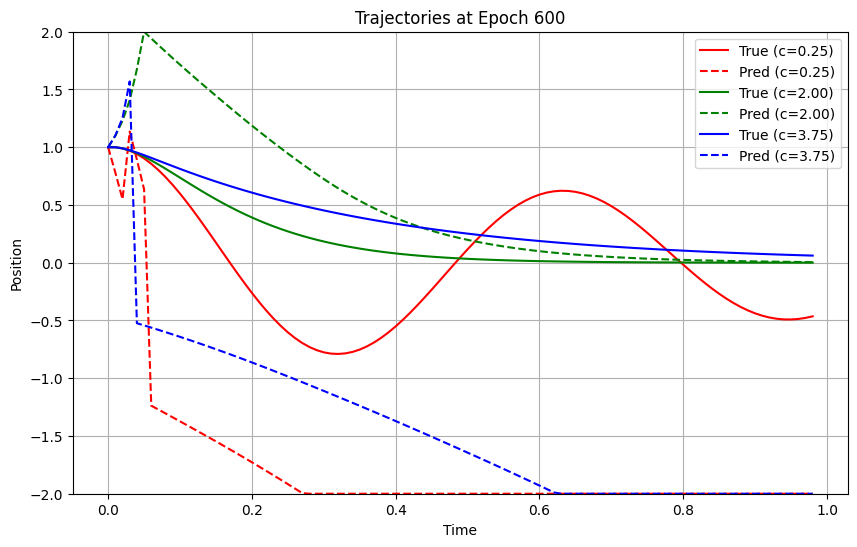

Epoch 700/1000, Loss: 0.4522155225276947


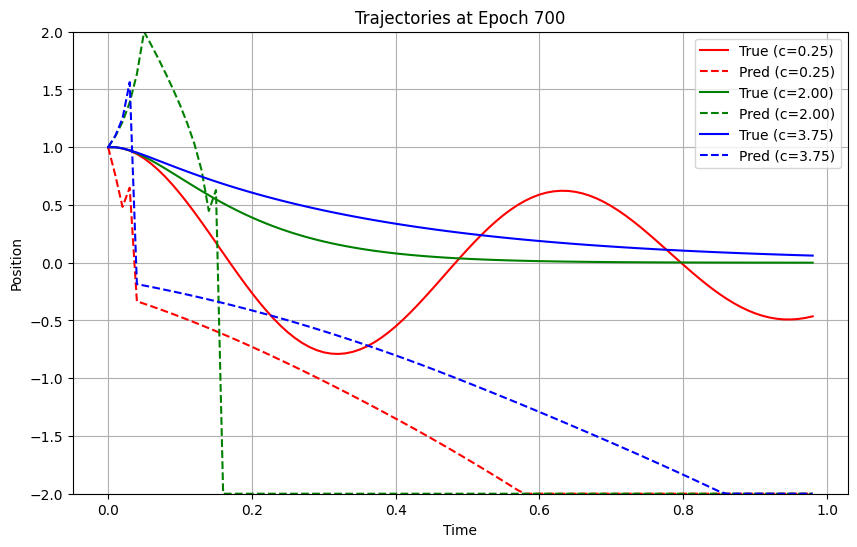

Epoch 800/1000, Loss: 0.4372469186782837


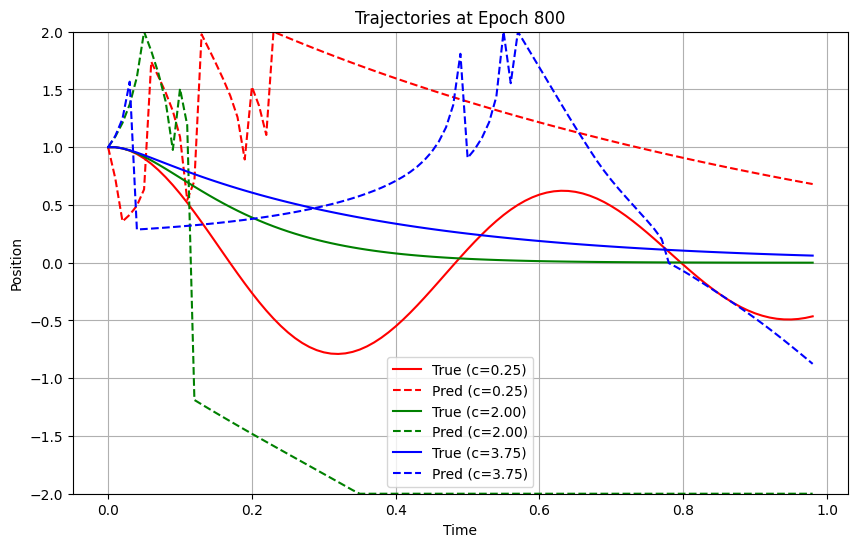

Epoch 900/1000, Loss: 0.42079246044158936


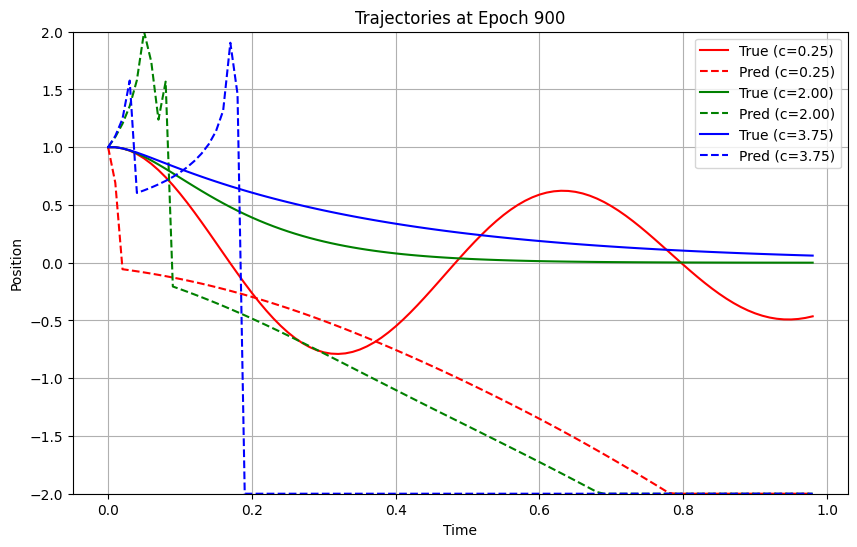

Epoch 1000/1000, Loss: 0.4091786742210388


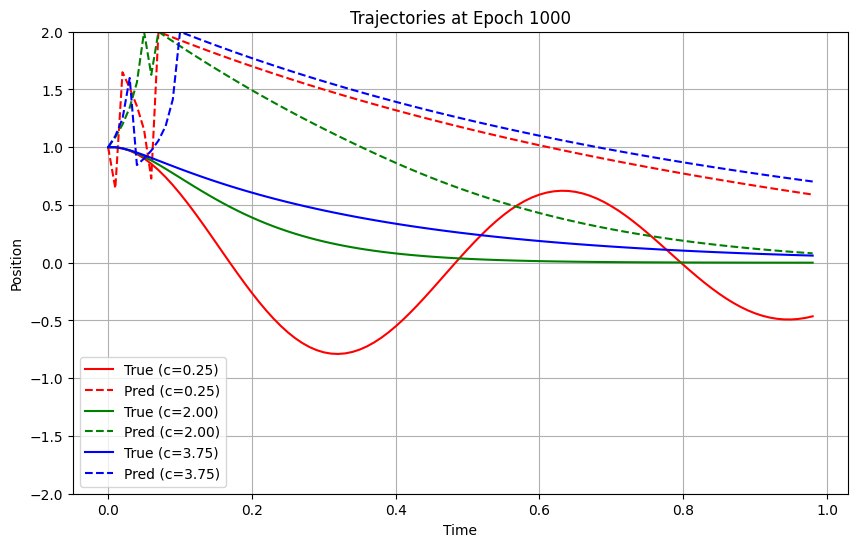

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import pickle

# First, the dataset and dataloader classes
class OscillationDataset(Dataset):
    def __init__(self, df, groupby='HADM_ID'):
        self.df = df
        self.groupby = groupby
        self.groups = list(df.groupby(groupby))
        
    def __len__(self):
        return len(self.groups)
    
    def __getitem__(self, idx):
        _, group = self.groups[idx]
        group = group.sort_values('t')
        
        # Get trajectory data
        x = torch.FloatTensor(group['x'].values).unsqueeze(-1)  # [T, 1]
        c = torch.FloatTensor([group['c'].iloc[0]]).unsqueeze(-1)  # [1, 1]
        t = torch.FloatTensor(group['t'].values)  # [T]
        
        # Create pairs of consecutive points
        x0 = x[:-1]  # [T-1, 1]
        x1 = x[1:]   # [T-1, 1]
        t0 = t[:-1]  # [T-1]
        t1 = t[1:]   # [T-1]
        
        # Expand condition to match sequence length
        c = c.expand(len(x0), -1)  # [T-1, 1]
        
        return x0, c, x1, t0.unsqueeze(-1), t1.unsqueeze(-1)

    @staticmethod
    def collate_fn(batch):
        # Unzip the batch
        x0s, cs, x1s, t0s, t1s = zip(*batch)
        
        # Concatenate along batch dimension
        x0 = torch.cat(x0s, dim=0)  # [B*T, 1]
        c = torch.cat(cs, dim=0)    # [B*T, 1]
        x1 = torch.cat(x1s, dim=0)  # [B*T, 1]
        t0 = torch.cat(t0s, dim=0)  # [B*T, 1]
        t1 = torch.cat(t1s, dim=0)  # [B*T, 1]
        
        return x0, c, x1, t0, t1

class OscillationDataLoader:
    def __init__(self, file_path, batch_size=32):
        self.batch_size = batch_size
        
        # Load data
        with open(file_path, 'rb') as f:
            self.data = pickle.load(f)
            
        # Create datasets
        self.train_dataset = OscillationDataset(self.data['train'])
        self.val_dataset = OscillationDataset(self.data['val'])
        self.test_dataset = OscillationDataset(self.data['test'])
        
        # Define dimensions
        self.input_dim = 1  # position
        self.cond_dim = 1   # damping coefficient
    
    def get_train_loader(self, shuffle=True):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=shuffle,
            collate_fn=OscillationDataset.collate_fn
        )
    
    def get_val_loader(self):
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            collate_fn=OscillationDataset.collate_fn
        )
    
    def get_test_loader(self):
        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            collate_fn=OscillationDataset.collate_fn
        )

def train_model(model, noise_prediction, train_loader, val_loader=None, num_epochs=1000, device='cuda'):
    model.to(device)

    if noise_prediction: 
        flow_optimizer, noise_optimizer = model.configure_optimizers()
    else: 
        optimizer = model.configure_optimizers()

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        
        for batch_idx, batch in enumerate(train_loader):
            x0, x0_class, x1, x0_time, x1_time = [b.to(device) for b in batch]
            
            x, ut, t_model, futuretime, t = model.__x_processing__(x0, x1, x0_time, x1_time)
            
            # Concatenate state, condition, and time
            in_tensor = torch.cat([x, x0_class, t_model], dim=-1)

            if noise_prediction: 
                xt = model.flow_model.forward_train(in_tensor)

                if model.implementation == "SDE":
                    sde_noise = model.noise_model.forward_train(in_tensor)
                    variance = torch.sqrt(t * (1 - t)) * sde_noise
                    noise = torch.randn_like(xt[:, :model.dim]) * variance
                    
                    loss = F.mse_loss(xt[:, :model.dim] + noise.clone().detach(), x1) + \
                           F.mse_loss(xt[:, -1], futuretime)
                    uncertainty = (xt[:, :model.dim].clone().detach() + noise)
                    noise_loss = F.mse_loss(uncertainty, x1)

                    flow_optimizer.zero_grad()
                    loss.backward()
                    flow_optimizer.step()

                    noise_optimizer.zero_grad()
                    noise_loss.backward()
                    noise_optimizer.step()

                    train_loss += (loss + noise_loss).item()
                else:
                    loss = F.mse_loss(xt[:, :model.dim], x1) + F.mse_loss(xt[:, -1], futuretime)
                    uncertainty = torch.abs(xt[:, :model.dim].clone().detach() - x1)
                    noise_loss = F.mse_loss(model.noise_model.forward_train(in_tensor), uncertainty)

                    flow_optimizer.zero_grad()
                    loss.backward()
                    flow_optimizer.step()

                    noise_optimizer.zero_grad()
                    noise_loss.backward()
                    noise_optimizer.step()

                    train_loss += (loss + noise_loss).item()
            else:
                xt = model.flow_model.forward_train(in_tensor)
                if model.implementation == "SDE":
                    variance = t * (1 - t) * model.sde_noise
                    noise = torch.randn_like(xt[:, :model.dim]) * torch.sqrt(variance)
                    loss = F.mse_loss(xt[:, :model.dim] + noise, x1)
                else:
                    loss = F.mse_loss(xt[:, :model.dim], x1)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                train_loss += loss.item()

        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {train_loss/len(train_loader)}")
            if val_loader:
                visualize_trajectories(model, val_loader, epoch + 1, device)

def visualize_trajectories(model, val_loader, epoch, device):
    model.eval()
    with torch.no_grad():
        # Get one batch of validation data
        x0, x0_class, x1, x0_time, x1_time = next(iter(val_loader))
        x0, x0_class, x1, x0_time, x1_time = [b.to(device) for b in [x0, x0_class, x1, x0_time, x1_time]]
        
        # Plot setup
        plt.figure(figsize=(10, 6))
        colors = ['red', 'green', 'blue']
        damping_coeffs = [0.25, 2.0, 3.75]
        
        # For each damping coefficient
        for i, c_val in enumerate(damping_coeffs):
            mask = (x0_class[:, 0] == c_val)
            indices = torch.where(mask)[0]
            
            if len(indices) == 0:
                continue
            
            # Get the full trajectory for this damping coefficient
            traj_x0 = x0[mask]
            traj_t0 = x0_time[mask]
            
            # True trajectory
            true_x = traj_x0.squeeze().cpu().numpy()
            true_t = traj_t0.squeeze().cpu().numpy()
            
            # Generate predicted trajectory
            current_state = model.init_augmented_state(traj_x0[0:1])
            pred_trajectory = [traj_x0[0, 0].cpu().item()]
            pred_times = [traj_t0[0, 0].cpu().item()]
            
            # Use smaller time steps for stability
            dt = torch.tensor(0.005, device=device)  # Reduced from 0.01 to 0.005
            
            for j in range(len(traj_x0)-1):
                t = traj_t0[j]
                
                # Forward pass
                c_tensor = torch.tensor([[c_val]], device=device)
                drift = model.f(t.unsqueeze(0), current_state, condition=c_tensor)
                diffusion = model.g(t.unsqueeze(0), current_state)
                
                # Euler-Maruyama step with reduced noise
                dW = torch.randn_like(current_state) * torch.sqrt(dt)
                next_state = current_state + drift * dt + diffusion * dW
                
                # Clip values to prevent explosion
                x, noise = model.augmented_state(next_state)
                x = torch.clamp(x, -2, 2)  # Clip position to reasonable range
                next_state = torch.cat([x, noise], dim=-1)
                
                # Store prediction
                pred_trajectory.append(x[0, 0].cpu().item())
                pred_times.append(traj_t0[j+1].cpu().item())
                
                current_state = next_state
            
            # Plot with fixed y-axis limits
            plt.plot(true_t, true_x, color=colors[i], linestyle='-',
                    label=f'True (c={c_val:.2f})')
            plt.plot(pred_times, pred_trajectory, color=colors[i], linestyle='--',
                    label=f'Pred (c={c_val:.2f})')
    
    plt.title(f'Trajectories at Epoch {epoch}')
    plt.xlabel('Time')
    plt.ylabel('Position')
    plt.ylim(-2, 2)  # Fix y-axis limits
    plt.legend()
    plt.grid(True)
    plt.show()

# Initialize dataloader
data_loader = OscillationDataLoader(
    file_path="3Oscillation_data.pkl",
    batch_size=32
)

# Get dataloaders
train_loader = data_loader.get_train_loader()
val_loader = data_loader.get_val_loader()
test_loader = data_loader.get_test_loader()

# Initialize model
model = NonMarkovianSDEModel(
    treatment_cond=1,  # damping coefficient
    memory=3,         # Use memory of past states
    dim=1,           # position
    w=64,            # hidden dimension
    lr=1e-6,         # learning rate
    sigma=0.01,      # noise scale
    implementation="SDE",
    sde_noise=0.01   # SDE noise scale
)

# Print model structure
print("\nModel structure:")
print(model)

# Train model
train_model(
    model=model,
    noise_prediction=True,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=1000,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [36]:
import optuna
import torch
import torch.nn.functional as F

def objective(trial):
    # Define hyperparameters to tune
    lr = trial.suggest_loguniform('lr', 1e-6, 1e-2)
    sigma = trial.suggest_loguniform('sigma', 1e-4, 1e-1)
    sde_noise = trial.suggest_loguniform('sde_noise', 1e-4, 1e-1)
    w = trial.suggest_int('w', 32, 128)
    dropout_rate = trial.suggest_uniform('dropout_rate', 0.1, 0.5)
    weight_decay = trial.suggest_loguniform('weight_decay', 1e-6, 1e-2)
    num_layers = trial.suggest_int('num_layers', 2, 5)
    activation = trial.suggest_categorical('activation', ['SELU', 'ReLU', 'LeakyReLU', 'Tanh'])

    # Define the activation function
    if activation == 'SELU':
        activation_fn = torch.nn.SELU()
    elif activation == 'ReLU':
        activation_fn = torch.nn.ReLU()
    elif activation == 'LeakyReLU':
        activation_fn = torch.nn.LeakyReLU()
    elif activation == 'Tanh':
        activation_fn = torch.nn.Tanh()

    # Define the model with the suggested hyperparameters
    class NonMarkovianDriftNet(nn.Module):
        def __init__(self, dim, treatment_cond, memory, w, num_layers, activation_fn, dropout_rate):
            super().__init__()
            self.dim = dim
            self.memory = memory
            self.treatment_cond = treatment_cond
            
            self.indim = dim + treatment_cond + 1 + (dim * memory)
            self.out_dim = dim + 1
            
            layers = []
            layers.append(nn.Linear(self.indim, w))
            layers.append(activation_fn)
            layers.append(nn.Dropout(dropout_rate))
            for _ in range(num_layers - 1):
                layers.append(nn.Linear(w, w))
                layers.append(activation_fn)
                layers.append(nn.Dropout(dropout_rate))
            layers.append(nn.Linear(w, self.out_dim))
            
            self.net = nn.Sequential(*layers)

        def forward_train(self, x):
            return self.net(x)

        def forward(self, x):
            x1 = self.forward_train(x)
            x1_coord = x1[:, :self.dim]
            t = x[:, -1:]
            pred_time_till_t1 = x1[:, -1:]
            x_coord = x[:, :self.dim]
            vt = (x1_coord - x_coord)/(pred_time_till_t1 + 1e-6)
            return vt

    class NonMarkovianNoiseNet(nn.Module):
        def __init__(self, dim, treatment_cond, memory, w, num_layers, activation_fn, dropout_rate):
            super().__init__()
            self.dim = dim
            self.memory = memory
            self.treatment_cond = treatment_cond
            
            self.indim = dim + treatment_cond + 1 + (dim * memory)
            self.out_dim = 1
            
            layers = []
            layers.append(nn.Linear(self.indim, w))
            layers.append(activation_fn)
            layers.append(nn.Dropout(dropout_rate))
            for _ in range(num_layers - 1):
                layers.append(nn.Linear(w, w))
                layers.append(activation_fn)
                layers.append(nn.Dropout(dropout_rate))
            layers.append(nn.Linear(w, self.out_dim))
            
            self.net = nn.Sequential(*layers)

        def forward_train(self, x):
            return self.net(x)

        def forward(self, x):
            return self.forward_train(x)

    class NonMarkovianSDEModel(nn.Module):
        def __init__(self, treatment_cond, memory=3, dim=1, w=64, lr=1e-6, sigma=0.01, implementation="SDE", sde_noise=0.01, weight_decay=1e-4, num_layers=3, activation_fn=torch.nn.SELU(), dropout_rate=0.2):
            super().__init__()
            self.memory = memory
            self.dim = dim
            self.implementation = implementation
            self.sde_noise = sde_noise
            self.sigma = sigma
            self.lr = lr
            self.weight_decay = weight_decay
            
            self.flow_model = NonMarkovianDriftNet(dim=dim, treatment_cond=treatment_cond, memory=memory, w=w, num_layers=num_layers, activation_fn=activation_fn, dropout_rate=dropout_rate)
            
            if implementation == "SDE":
                self.noise_model = NonMarkovianNoiseNet(dim=dim, treatment_cond=treatment_cond, memory=memory, w=w, num_layers=num_layers, activation_fn=activation_fn, dropout_rate=dropout_rate)

        def forward(self, x):
            return self.flow_model(x)

        def configure_optimizers(self):
            flow_optimizer = torch.optim.Adam(self.flow_model.parameters(), lr=self.lr, weight_decay=self.weight_decay)
            noise_optimizer = torch.optim.Adam(self.noise_model.parameters(), lr=self.lr, weight_decay=self.weight_decay)
            return flow_optimizer, noise_optimizer

        def __x_processing__(self, x0, x1, t0, t1):
            t = torch.rand(x0.shape[0], 1).to(x0.device)
            mu_t = x0 * (1 - t) + x1 * t
            data_t_diff = t1 - t0
            x = mu_t + self.sigma * torch.randn_like(x0)
            ut = (x1 - x0) / (data_t_diff + 1e-4)
            t_model = t * data_t_diff + t0
            futuretime = t1 - t_model
            
            memory = torch.zeros(x0.shape[0], self.dim * self.memory, device=x0.device)
            x = torch.cat([x, memory], dim=-1)
            
            return x, ut, t_model, futuretime, t

    # Initialize model with suggested hyperparameters
    model = NonMarkovianSDEModel(
        treatment_cond=1,
        memory=3,
        dim=1,
        w=w,
        lr=lr,
        sigma=sigma,
        implementation="SDE",
        sde_noise=sde_noise,
        weight_decay=weight_decay,
        num_layers=num_layers,
        activation_fn=activation_fn,
        dropout_rate=dropout_rate
    ).to(device)

    # Define optimizers
    flow_optimizer, noise_optimizer = model.configure_optimizers()

    # Training loop
    num_epochs = 100
    train_loss = 0
    for epoch in range(num_epochs):
        model.train()
        for batch in train_loader:
            x0, x0_class, x1, x0_time, x1_time = [b.to(device) for b in batch]
            x, ut, t_model, futuretime, t = model.__x_processing__(x0, x1, x0_time, x1_time)
            in_tensor = torch.cat([x, x0_class, t_model], dim=-1)

            xt = model.flow_model.forward_train(in_tensor)
            sde_noise = model.noise_model.forward_train(in_tensor)
            variance = torch.sqrt(t * (1 - t)) * sde_noise
            noise = torch.randn_like(xt[:, :model.dim]) * variance

            loss = F.mse_loss(xt[:, :model.dim] + noise.clone().detach(), x1) + \
                   F.mse_loss(xt[:, -1], futuretime)
            uncertainty = (xt[:, :model.dim].clone().detach() + noise)
            noise_loss = F.mse_loss(uncertainty, x1)

            flow_optimizer.zero_grad()
            loss.backward()
            flow_optimizer.step()

            noise_optimizer.zero_grad()
            noise_loss.backward()
            noise_optimizer.step()

            train_loss += (loss + noise_loss).item()

    # Return the average training loss
    return train_loss / (num_epochs * len(train_loader))

# Create a study and optimize the objective function
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

# Print the best hyperparameters
print("Best hyperparameters: ", study.best_params)

[I 2025-01-15 12:02:19,922] A new study created in memory with name: no-name-254e769b-f327-48b3-8015-b423d4a26789
/var/folders/93/ntgmx7vs74j7k7hwjjw8n70m0000gn/T/ipykernel_15804/3193880028.py:162: UserWarning: Using a target size (torch.Size([297, 1])) that is different to the input size (torch.Size([297])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  F.mse_loss(xt[:, -1], futuretime)
[I 2025-01-15 12:02:20,259] Trial 0 finished with value: 0.49000495821237566 and parameters: {'lr': 6.042748265465956e-06, 'sigma': 0.0005590354226089484, 'sde_noise': 0.06858718852049558, 'w': 36, 'dropout_rate': 0.37244236747554177, 'weight_decay': 0.00022839741839024698, 'num_layers': 5, 'activation': 'Tanh'}. Best is trial 0 with value: 0.49000495821237566.
/var/folders/93/ntgmx7vs74j7k7hwjjw8n70m0000gn/T/ipykernel_15804/3193880028.py:162: UserWarning: Using a target size (torch.Size([297, 1])) that is different to the input size (torch.Siz

Best hyperparameters:  {'lr': 0.002825074076877614, 'sigma': 0.00017326381754200496, 'sde_noise': 0.0020370465800183283, 'w': 122, 'dropout_rate': 0.10334578569164665, 'weight_decay': 0.0006281623981020038, 'num_layers': 2, 'activation': 'LeakyReLU'}



Model structure:
NonMarkovianSDEModel(
  (flow_model): NonMarkovianDriftNet(
    (net): Sequential(
      (0): Linear(in_features=6, out_features=202, bias=True)
      (1): SELU()
      (2): Dropout(p=0.0035039585497148463, inplace=False)
      (3): Linear(in_features=202, out_features=202, bias=True)
      (4): SELU()
      (5): Dropout(p=0.0035039585497148463, inplace=False)
      (6): Linear(in_features=202, out_features=202, bias=True)
      (7): SELU()
      (8): Dropout(p=0.0035039585497148463, inplace=False)
      (9): Linear(in_features=202, out_features=202, bias=True)
      (10): SELU()
      (11): Dropout(p=0.0035039585497148463, inplace=False)
      (12): Linear(in_features=202, out_features=202, bias=True)
      (13): SELU()
      (14): Dropout(p=0.0035039585497148463, inplace=False)
      (15): Linear(in_features=202, out_features=202, bias=True)
      (16): SELU()
      (17): Dropout(p=0.0035039585497148463, inplace=False)
      (18): Linear(in_features=202, out_feature

/var/folders/93/ntgmx7vs74j7k7hwjjw8n70m0000gn/T/ipykernel_15804/2237263964.py:123: UserWarning: Using a target size (torch.Size([297, 1])) that is different to the input size (torch.Size([297])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  F.mse_loss(xt[:, -1], futuretime)


Epoch 100/1000, Loss: 0.0017502885311841965


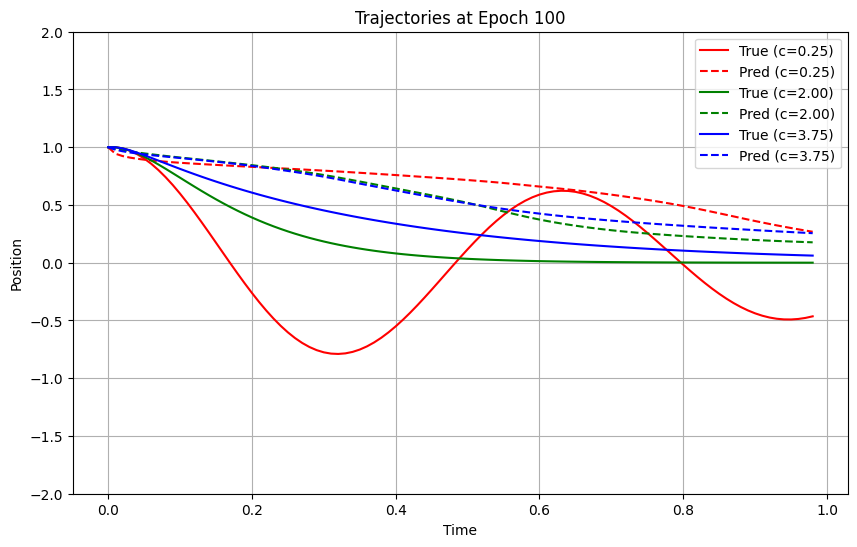

Epoch 200/1000, Loss: 0.001493736868724227


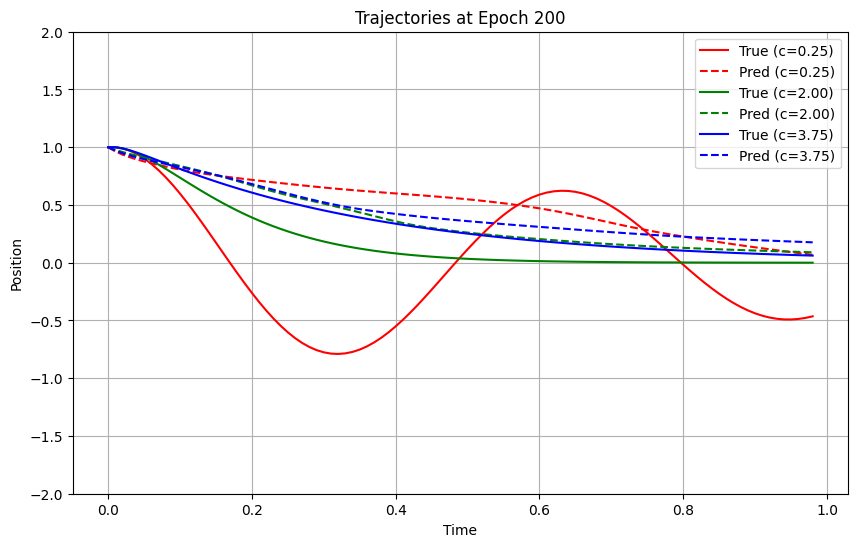

Epoch 300/1000, Loss: 0.0011882227845489979


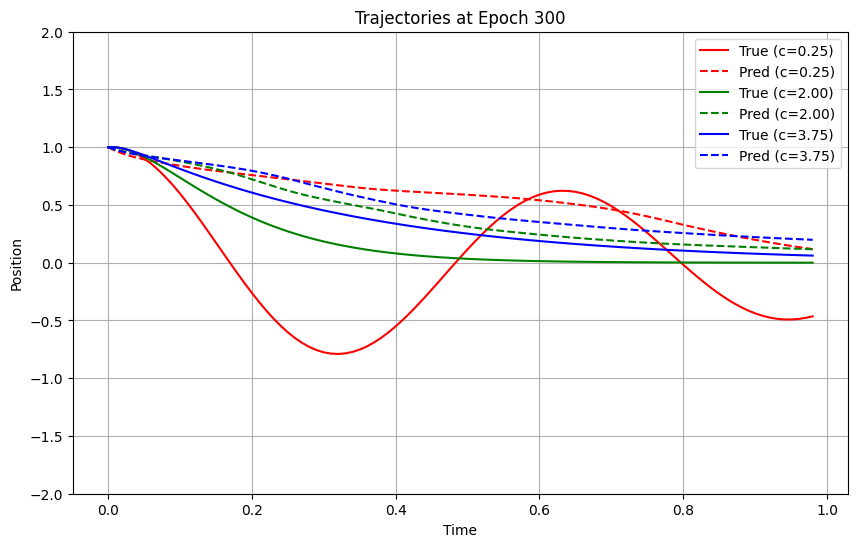

Epoch 400/1000, Loss: 0.0012083012843504548


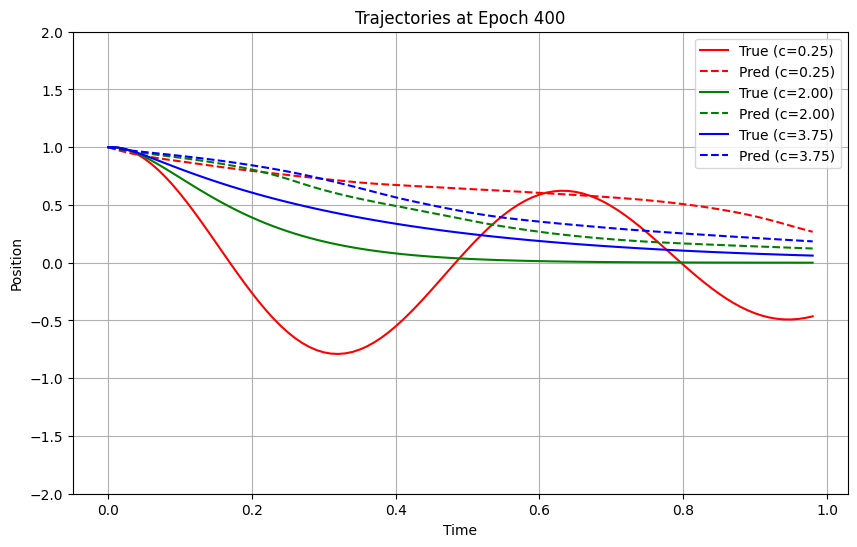

Epoch 500/1000, Loss: 0.0008284540381282568


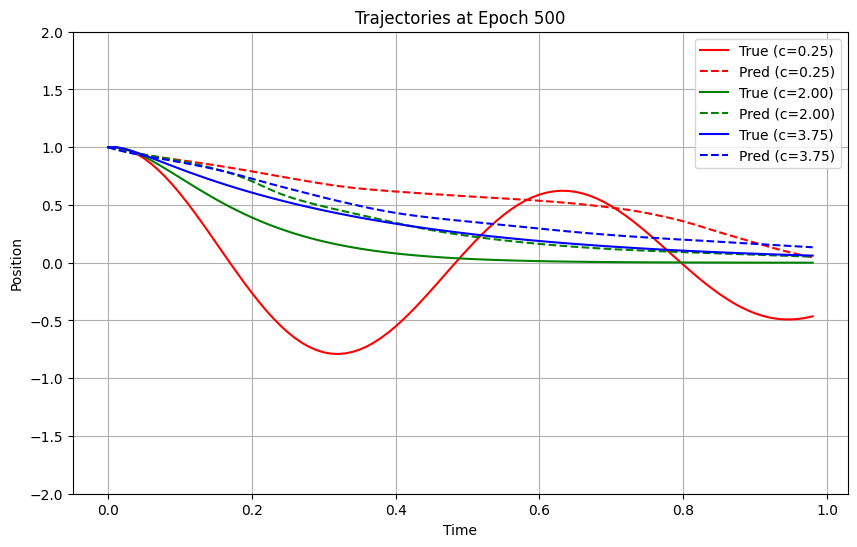

Epoch 600/1000, Loss: 0.001372546423226595


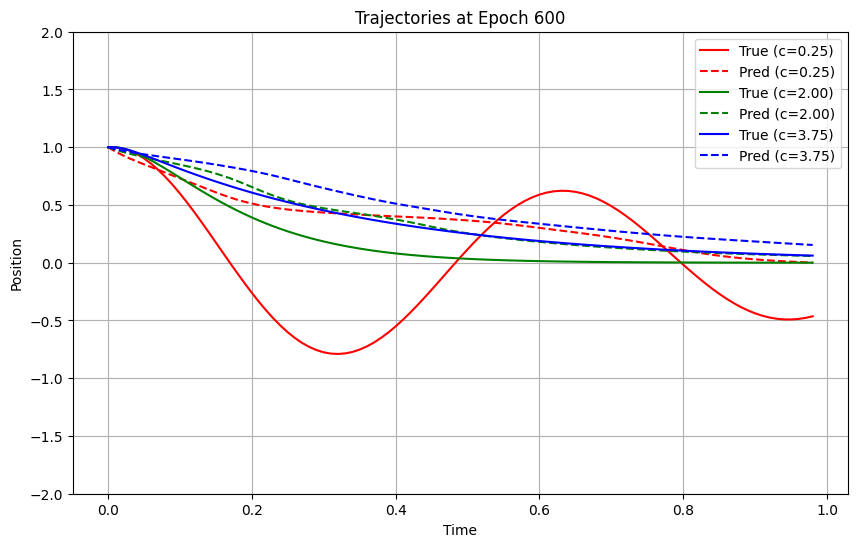

Epoch 700/1000, Loss: 0.0009488779469393194


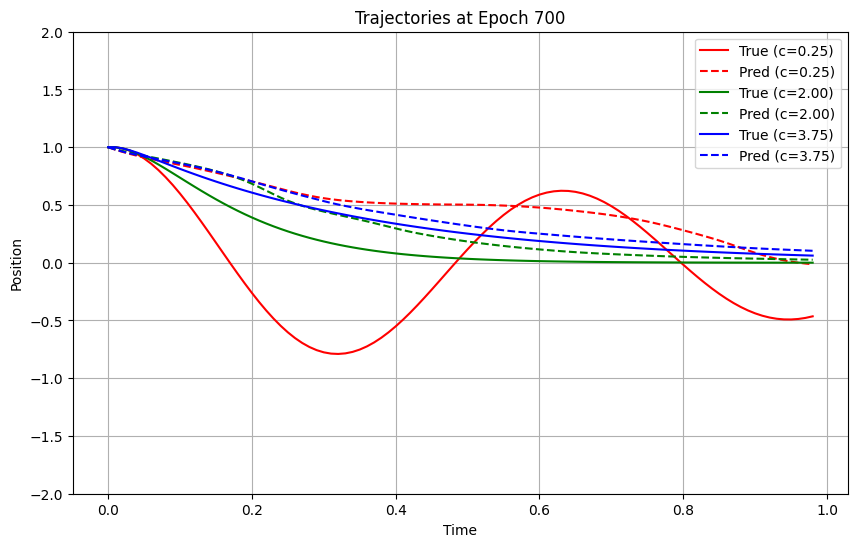

Epoch 800/1000, Loss: 0.0008839560905471444


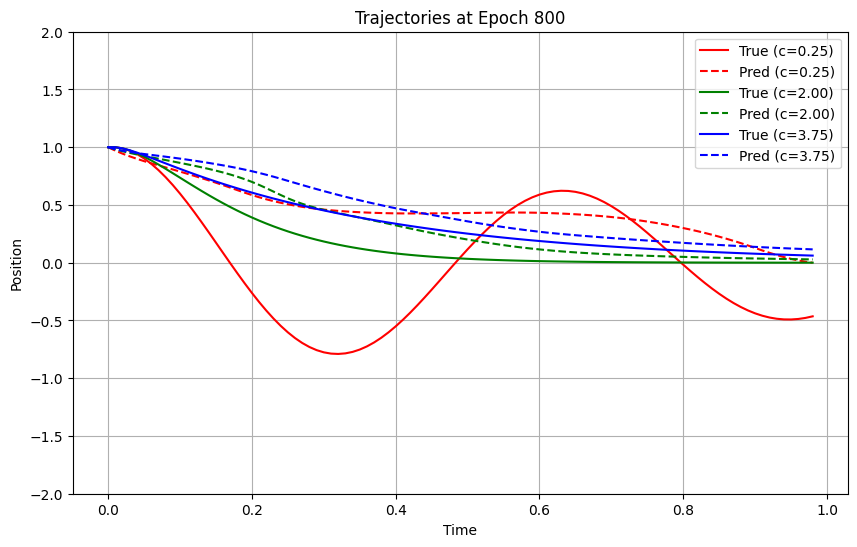

Epoch 900/1000, Loss: 0.0008387572597712278


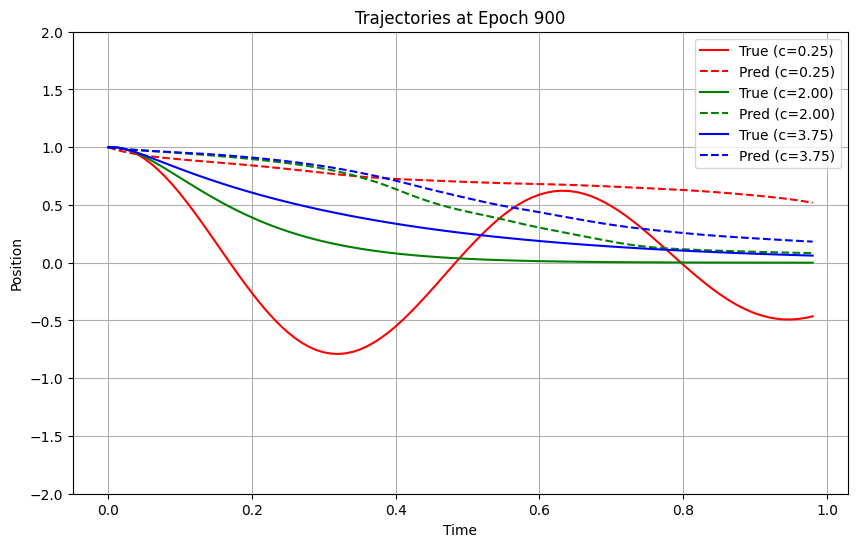

Epoch 1000/1000, Loss: 0.0009519826853647828


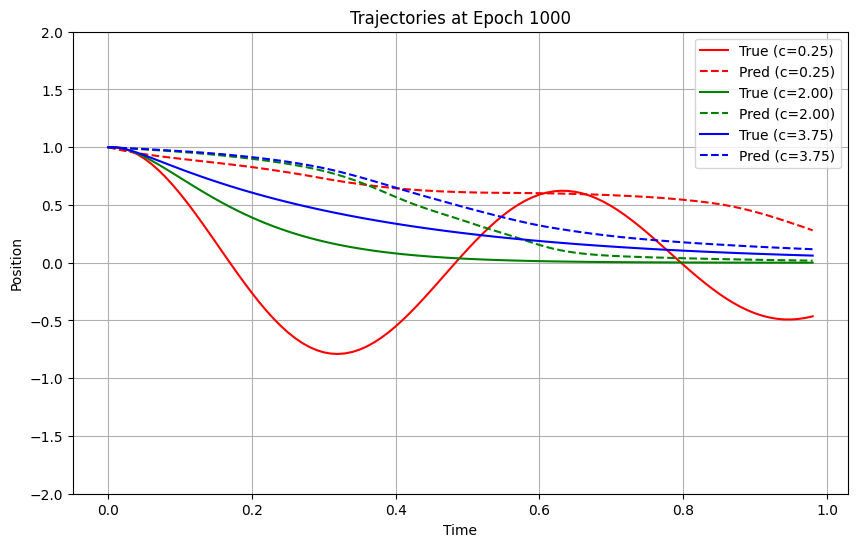

In [59]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import pickle

# First, the dataset and dataloader classes
class OscillationDataset(Dataset):
    def __init__(self, df, groupby='HADM_ID'):
        self.df = df
        self.groupby = groupby
        self.groups = list(df.groupby(groupby))
        
    def __len__(self):
        return len(self.groups)
    
    def __getitem__(self, idx):
        _, group = self.groups[idx]
        group = group.sort_values('t')
        
        # Get trajectory data
        x = torch.FloatTensor(group['x'].values).unsqueeze(-1)  # [T, 1]
        c = torch.FloatTensor([group['c'].iloc[0]]).unsqueeze(-1)  # [1, 1]
        t = torch.FloatTensor(group['t'].values)  # [T]
        
        # Create pairs of consecutive points
        x0 = x[:-1]  # [T-1, 1]
        x1 = x[1:]   # [T-1, 1]
        t0 = t[:-1]  # [T-1]
        t1 = t[1:]   # [T-1]
        
        # Expand condition to match sequence length
        c = c.expand(len(x0), -1)  # [T-1, 1]
        
        return x0, c, x1, t0.unsqueeze(-1), t1.unsqueeze(-1)

    @staticmethod
    def collate_fn(batch):
        # Unzip the batch
        x0s, cs, x1s, t0s, t1s = zip(*batch)
        
        # Concatenate along batch dimension
        x0 = torch.cat(x0s, dim=0)  # [B*T, 1]
        c = torch.cat(cs, dim=0)    # [B*T, 1]
        x1 = torch.cat(x1s, dim=0)  # [B*T, 1]
        t0 = torch.cat(t0s, dim=0)  # [B*T, 1]
        t1 = torch.cat(t1s, dim=0)  # [B*T, 1]
        
        return x0, c, x1, t0, t1

class OscillationDataLoader:
    def __init__(self, file_path, batch_size=32):
        self.batch_size = batch_size
        
        # Load data
        with open(file_path, 'rb') as f:
            self.data = pickle.load(f)
            
        # Create datasets
        self.train_dataset = OscillationDataset(self.data['train'])
        self.val_dataset = OscillationDataset(self.data['val'])
        self.test_dataset = OscillationDataset(self.data['test'])
        
        # Define dimensions
        self.input_dim = 1  # position
        self.cond_dim = 1   # damping coefficient
    
    def get_train_loader(self, shuffle=True):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=shuffle,
            collate_fn=OscillationDataset.collate_fn
        )
    
    def get_val_loader(self):
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            collate_fn=OscillationDataset.collate_fn
        )
    
    def get_test_loader(self):
        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            collate_fn=OscillationDataset.collate_fn
        )

def train_model(model, noise_prediction, train_loader, val_loader=None, num_epochs=1000, device='cuda'):
    model.to(device)

    if noise_prediction: 
        flow_optimizer, noise_optimizer = model.configure_optimizers()
    else: 
        optimizer = model.configure_optimizers()

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        
        for batch_idx, batch in enumerate(train_loader):
            x0, x0_class, x1, x0_time, x1_time = [b.to(device) for b in batch]
            
            x, ut, t_model, futuretime, t = model.__x_processing__(x0, x1, x0_time, x1_time)
            
            # Concatenate state, condition, and time
            in_tensor = torch.cat([x, x0_class, t_model], dim=-1)

            if noise_prediction: 
                xt = model.flow_model.forward_train(in_tensor)

                if model.implementation == "SDE":
                    sde_noise = model.noise_model.forward_train(in_tensor)
                    variance = torch.sqrt(t * (1 - t)) * sde_noise
                    noise = torch.randn_like(xt[:, :model.dim]) * variance
                    
                    loss = F.mse_loss(xt[:, :model.dim] + noise.clone().detach(), x1) + \
                           F.mse_loss(xt[:, -1], futuretime)
                    uncertainty = (xt[:, :model.dim].clone().detach() + noise)
                    noise_loss = F.mse_loss(uncertainty, x1)

                    flow_optimizer.zero_grad()
                    loss.backward()
                    flow_optimizer.step()

                    noise_optimizer.zero_grad()
                    noise_loss.backward()
                    noise_optimizer.step()

                    train_loss += (loss + noise_loss).item()
                else:
                    loss = F.mse_loss(xt[:, :model.dim], x1) + F.mse_loss(xt[:, -1], futuretime)
                    uncertainty = torch.abs(xt[:, :model.dim].clone().detach() - x1)
                    noise_loss = F.mse_loss(model.noise_model.forward_train(in_tensor), uncertainty)

                    flow_optimizer.zero_grad()
                    loss.backward()
                    flow_optimizer.step()

                    noise_optimizer.zero_grad()
                    noise_loss.backward()
                    noise_optimizer.step()

                    train_loss += (loss + noise_loss).item()
            else:
                xt = model.flow_model.forward_train(in_tensor)
                if model.implementation == "SDE":
                    variance = t * (1 - t) * model.sde_noise
                    noise = torch.randn_like(xt[:, :model.dim]) * torch.sqrt(variance)
                    loss = F.mse_loss(xt[:, :model.dim] + noise, x1)
                else:
                    loss = F.mse_loss(xt[:, :model.dim], x1)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                train_loss += loss.item()

        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {train_loss/len(train_loader)}")
            if val_loader:
                visualize_trajectories(model, val_loader, epoch + 1, device)

def visualize_trajectories(model, val_loader, epoch, device):
    model.eval()
    with torch.no_grad():
        # Get one batch of validation data
        x0, x0_class, x1, x0_time, x1_time = next(iter(val_loader))
        x0, x0_class, x1, x0_time, x1_time = [b.to(device) for b in [x0, x0_class, x1, x0_time, x1_time]]
        
        # Plot setup
        plt.figure(figsize=(10, 6))
        colors = ['red', 'green', 'blue']
        damping_coeffs = [0.25, 2.0, 3.75]
        
        # For each damping coefficient
        for i, c_val in enumerate(damping_coeffs):
            mask = (x0_class[:, 0] == c_val)
            indices = torch.where(mask)[0]
            
            if len(indices) == 0:
                continue
            
            # Get the full trajectory for this damping coefficient
            traj_x0 = x0[mask]
            traj_t0 = x0_time[mask]
            
            # True trajectory
            true_x = traj_x0.squeeze().cpu().numpy()
            true_t = traj_t0.squeeze().cpu().numpy()
            
            # Generate predicted trajectory
            current_state = model.init_augmented_state(traj_x0[0:1])
            pred_trajectory = [traj_x0[0, 0].cpu().item()]
            pred_times = [traj_t0[0, 0].cpu().item()]
            
            # Use smaller time steps for stability
            dt = torch.tensor(0.005, device=device)  # Reduced from 0.01 to 0.005
            
            for j in range(len(traj_x0)-1):
                t = traj_t0[j]
                
                # Forward pass
                c_tensor = torch.tensor([[c_val]], device=device)
                drift = model.f(t.unsqueeze(0), current_state, condition=c_tensor)
                diffusion = model.g(t.unsqueeze(0), current_state)
                
                # Euler-Maruyama step with reduced noise
                dW = torch.randn_like(current_state) * torch.sqrt(dt)
                next_state = current_state + drift * dt + diffusion * dW
                
                # Clip values to prevent explosion
                x, noise = model.augmented_state(next_state)
                x = torch.clamp(x, -2, 2)  # Clip position to reasonable range
                next_state = torch.cat([x, noise], dim=-1)
                
                # Store prediction
                pred_trajectory.append(x[0, 0].cpu().item())
                pred_times.append(traj_t0[j+1].cpu().item())
                
                current_state = next_state
            
            # Plot with fixed y-axis limits
            plt.plot(true_t, true_x, color=colors[i], linestyle='-',
                    label=f'True (c={c_val:.2f})')
            plt.plot(pred_times, pred_trajectory, color=colors[i], linestyle='--',
                    label=f'Pred (c={c_val:.2f})')
    
    plt.title(f'Trajectories at Epoch {epoch}')
    plt.xlabel('Time')
    plt.ylabel('Position')
    plt.ylim(-2, 2)  # Fix y-axis limits
    plt.legend()
    plt.grid(True)
    plt.show()

# Initialize dataloader
data_loader = OscillationDataLoader(
    file_path="3Oscillation_data.pkl",
    batch_size=32
)

# Get dataloaders
train_loader = data_loader.get_train_loader()
val_loader = data_loader.get_val_loader()
test_loader = data_loader.get_test_loader()

# Extract the best hyperparameters from the study
best_params = study.best_params

# Initialize the model with the best hyperparameters
model = NonMarkovianSDEModel(
    treatment_cond=1,  # damping coefficient
    memory=3,          # Use memory of past states
    dim=1,             # position
    w=best_params['w'],  # hidden dimension
    lr=best_params['lr'],  # learning rate
    sigma=best_params['sigma'],  # noise scale
    implementation="SDE",
    sde_noise=best_params['sde_noise'],  # SDE noise scale
    weight_decay=best_params['weight_decay'],  # weight decay
    num_layers=best_params['num_layers'],  # number of layers
    activation_fn=torch.nn.__dict__[best_params['activation']](),  # activation function
    dropout_rate=best_params['dropout_rate'],  # dropout rate
    loss_fn=F.mse_loss  # loss function
).to(device)

# Print model structure
print("\nModel structure:")
print(model)

# Train the model with the best hyperparameters
train_model(
    model=model,
    noise_prediction=True,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=1000,
    device=device
)